## SaaS Churn & Revenue Analytics Platform- PROJECT

* CloudMetrics is a B2B SaaS company selling analytics software on four plan tiers.Leadership has noticed revenue growth flattening despite steady new signups
* Churn = Customers are joining, but existing customers are leaving
* Four CSVs attached: saas_customers.csv, saas_subscriptions.csv, saas_usage.csv, saas_tickets.csv.


# MODULE 1 — Python Foundations:Build a loader with proper exception handling for missing or malformed files

In [ ]:
#IMPORT LIBRARIES:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

from pathlib import Path

In [ ]:
#  DEFINE THE FILE PATHS

Data_folder = Path("data")

customer_file = Data_folder/"/content/saas_customers.csv"
subscription_file = Data_folder/"/content/saas_subscriptions.csv"
tickets_file = Data_folder/"/content/saas_tickets.csv"
usage_file = Data_folder/"/content/saas_usage.csv"


In [ ]:
# LOAD CSV FILE - USING FILE EXCEPTION HANDLING:

def load_csv(file_path):

    try:
        df = pd.read_csv(file_path)

        print(f"SUCCESS: {file_path.name} loaded successfully.")
        return df

    except FileNotFoundError:
        print(f"ERROR: File not found -> {file_path}")
        return None

    except pd.errors.EmptyDataError:
        print(f"ERROR: File is empty -> {file_path}")
        return None

    except pd.errors.ParserError:
        print(f"ERROR: File is malformed -> {file_path}")
        return None

    except UnicodeDecodeError:
        print(f"ERROR: Encoding problem -> {file_path}")
        return None

    except Exception as e:
        print(f"ERROR: Unexpected error while loading {file_path}")
        print(f"Details: {e}")
        return None

#Write at least three reusable utility functions

In [ ]:
# REUSABLE UTILITY FUNCTIONS: VALIDATE SHAPE (number of rows and columns)

def validate_shape(df,file_name):
    rows,columns = df.shape
    print(f"\n{file_name} SHAPE")
    print("-"*40)
    print(f"Rows: {rows}")
    print(f"columns :{columns}")

In [ ]:
#REUSABLE UTILITY FUNCTIONS : VALIDATE COLUMNS

def validate_columns(df, expected_columns, file_name):

    actual_columns = set(df.columns)
    expected_columns = set(expected_columns)

    missing_columns = expected_columns - actual_columns
    extra_columns = actual_columns - expected_columns

    print(f"\n{file_name} COLUMNS")
    print("-" * 40)

    if not missing_columns:
        print("All expected columns are present.")
    else:
        print("Missing columns:")
        for column in sorted(missing_columns):
            print(f"  - {column}")

    if extra_columns:
        print("\nExtra columns found:")
        for column in sorted(extra_columns):
            print(f"  - {column}")

In [ ]:
#REUSABLE UTILITY FUNCTIONS : VALIDATE DATATYPES


def validate_dtypes(df, file_name):

    print(f"\n{file_name} DATA TYPES")
    print("-" * 40)

    print(df.dtypes)



In [ ]:
#REUSABLE UTILITY FUNCTIONS : VALIDATE MISSING VALUES

def check_missing_values(df, file_name):

    missing = df.isnull().sum()

    print(f"\n{file_name} MISSING VALUES")
    print("-" * 40)

    missing = missing[missing > 0]

    if missing.empty:
        print("No missing values found.")
    else:
        print(missing)

In [ ]:
#REUSABLE UTILITY FUNCTIONS : COMPLETE VALIDATION

def validate_dataset(df, expected_columns, file_name):

    if df is None:
        print(f"\nSkipping validation for {file_name}.")
        return

    print("\n")
    print("=" * 60)
    print(f"VALIDATING: {file_name}")
    print("=" * 60)

    validate_shape(df, file_name)

    validate_columns(
        df,
        expected_columns,
        file_name
    )

    validate_dtypes(
        df,
        file_name
    )

    check_missing_values(
        df,
        file_name
    )

In [ ]:
# LOAD 4 DATASETS:


print("LOADING CLOUDMETRICS DATASETS")



customers = load_csv(customer_file)

subscriptions = load_csv(subscription_file)

usage = load_csv(usage_file)

support_tickets = load_csv(tickets_file)

LOADING CLOUDMETRICS DATASETS
SUCCESS: saas_customers.csv loaded successfully.
SUCCESS: saas_subscriptions.csv loaded successfully.
SUCCESS: saas_usage.csv loaded successfully.
SUCCESS: saas_tickets.csv loaded successfully.


In [ ]:
# COLUMNS:

customers_columns = [
    "CustomerID",
    "CompanyName",
    "Industry",
    "Country",
    "City",
    "EmployeeCount",
    "SignupDate",
    "AcquisitionChannel"
]


subscriptions_columns = [
    "SubscriptionID",
    "CustomerID",
    "PlanName",
    "BillingTerm",
    "Seats",
    "MRR",
    "StartDate",
    "EndDate",
    "Status"
]



usage_columns = [
    "CustomerID",
    "SubscriptionID",
    "Month",
    "Logins",
    "ActiveUsers",
    "FeatureUsed",
    "APICalls",
    "SessionMinutes"
]



support_ticket_columns = [
    "TicketID",
    "CustomerID",
    "OpenedDate",
    "Category",
    "Priority",
    "ResolutionHours",
    "SatisfactionScore"
]

In [ ]:
# VALIDATE CUSTOMERS:

validate_dataset(
    customers,
    customers_columns,
    "Customers"
)



VALIDATING: Customers

Customers SHAPE
----------------------------------------
Rows: 425
columns :8

Customers COLUMNS
----------------------------------------
All expected columns are present.

Customers DATA TYPES
----------------------------------------
CustomerID             object
CompanyName            object
Industry               object
Country                object
City                   object
EmployeeCount         float64
SignupDate             object
AcquisitionChannel     object
dtype: object

Customers MISSING VALUES
----------------------------------------
Industry              10
EmployeeCount          5
AcquisitionChannel     6
dtype: int64


In [ ]:
# VALIDATE SUBSCRIPTION

validate_dataset(
    subscriptions,
    subscriptions_columns,
    "Subscriptions"
)




VALIDATING: Subscriptions

Subscriptions SHAPE
----------------------------------------
Rows: 448
columns :9

Subscriptions COLUMNS
----------------------------------------
All expected columns are present.

Subscriptions DATA TYPES
----------------------------------------
SubscriptionID     object
CustomerID         object
PlanName           object
BillingTerm        object
Seats             float64
MRR               float64
StartDate          object
EndDate            object
Status             object
dtype: object

Subscriptions MISSING VALUES
----------------------------------------
Seats        4
MRR          7
EndDate    318
dtype: int64


In [ ]:
# VALIDATE USAGE :


validate_dataset(
    usage,
    usage_columns,
    "Usage"
)



VALIDATING: Usage

Usage SHAPE
----------------------------------------
Rows: 4724
columns :8

Usage COLUMNS
----------------------------------------
All expected columns are present.

Usage DATA TYPES
----------------------------------------
CustomerID         object
SubscriptionID     object
Month              object
Logins              int64
ActiveUsers       float64
FeatureUsed        object
APICalls            int64
SessionMinutes    float64
dtype: object

Usage MISSING VALUES
----------------------------------------
ActiveUsers       15
SessionMinutes    25
dtype: int64


In [ ]:
validate_dataset(
    support_tickets,
    support_ticket_columns,
    "support_tickets"
)



VALIDATING: support_tickets

support_tickets SHAPE
----------------------------------------
Rows: 1409
columns :7

support_tickets COLUMNS
----------------------------------------
All expected columns are present.

support_tickets DATA TYPES
----------------------------------------
TicketID              object
CustomerID            object
OpenedDate            object
Category              object
Priority              object
ResolutionHours      float64
SatisfactionScore    float64
dtype: object

support_tickets MISSING VALUES
----------------------------------------
ResolutionHours      14
SatisfactionScore    22
dtype: int64


In [ ]:
# CHECK ALL DATASETS :
print("=" * 60)
print("DATASET PREVIEW")
print("=" * 60)


if customers is not None:
    print("\nCUSTOMERS")
    print(customers.head())


if subscriptions is not None:
    print("\nSUBSCRIPTIONS")
    print(subscriptions.head())


if usage is not None:
    print("\nUSAGE")
    print(usage.head())


if support_tickets is not None:
    print("\nSUPPORT TICKETS")
    print(support_tickets.head())

DATASET PREVIEW

CUSTOMERS
  CustomerID               CompanyName   Industry Country        City  \
0      C1001      Ishaan Joshi Systems        NaN   India   Hyderabad   
1      C1002  Tara Sharma Technologies    Finance      UK      London   
2      C1003          Zoya Das Systems    Finance     UAE       Dubai   
3      C1004           Diya Joshi Labs     Retail      UK  Manchester   
4      C1005        Tara Joshi Systems  Logistics      UK      London   

   EmployeeCount  SignupDate AcquisitionChannel  
0           80.0  2023-07-02           Paid Ads  
1           12.0  2024-02-21           Referral  
2         1200.0  2023-09-12     Organic Search  
3          400.0  2024-03-01            Partner  
4         1200.0  2023-12-29           Outbound  

SUBSCRIPTIONS
  SubscriptionID CustomerID  PlanName BillingTerm  Seats     MRR   StartDate  \
0          S5001      C1001    Growth     Monthly    6.0  278.60  2023-07-02   
1          S5002      C1002    Growth     Monthly    4.0  2

In [ ]:
# MODULE 1 COMPLETED

print("=" * 60)
print("MODULE 1 COMPLETED")
print("=" * 60)

print("Customers loaded       :", customers is not None)
print("Subscriptions loaded   :", subscriptions is not None)
print("Usage loaded           :", usage is not None)
print("Support tickets loaded :", support_tickets is not None)

print("\nValidation completed for all four datasets.")


MODULE 1 COMPLETED
Customers loaded       : True
Subscriptions loaded   : True
Usage loaded           : True
Support tickets loaded : True

Validation completed for all four datasets.


# MODULE - 2 (AUDIT AND CLEAN)

* audit  -> identify issues -> clean each issue separately -> log the action -> audit again.

* AUDIT -Shapes,datatypes, missing values, duplicate rows, unique values for text columns

* CLEAN INDIVIDUALLY - Dont use fillna()

* STANDARDIZE TEXT

* REFERENTIAL INTEGRITY - Need to check relationships

In [ ]:
# DATA CLEANING LOG:

cleaning_log=[]


def add_log(table,issues,row_affected, action,why):
  cleaning_log.append({
      "Table":table,
      "Issues":issues,
      "Row_affected":row_affected,
      "Action":action,
      "Why":why
  })

In [ ]:
#AUDIT FUNCTION:

def audit_datasets(df,table_name):
  print("="*80)
  print(f"AUDIT REPORT: {table_name}")
  print("="*80)

# SHAPE:

  print("\n1. SHAPE")
  print("-" * 50)

  print(f"Rows    : {df.shape[0]}")
  print(f"Columns : {df.shape[1]}")
  print(f"Shape   : {df.shape}")

  #DTYPES:

  print("\n2. DATA TYPES")
  print("-" * 50)

  print(df.dtypes)


  # MISSING VALUES

  print("\n3. MISSING VALUES")
  print("-" * 50)

  missing = df.isnull().sum()

  if missing.sum() == 0:
    print("No missing values.")

  else:
    print(missing[missing > 0])

    # DUPLICATE ROWS:

    print("\n4. DUPLICATE ROWS")
    print("-" * 50)

    duplicate_rows = df.duplicated().sum()

    print(f" duplicate rows: {duplicate_rows}")

    # UNIQUE VALUES FOR TEXT COLUMNS:


    print("\n5. UNIQUE VALUES - TEXT COLUMNS")
    print("-" * 50)

    text_columns = df.select_dtypes(
        include=["object", "string", "category"]
    ).columns

    if len(text_columns) == 0:
        print("No text columns found.")

    else:

        for column in text_columns:

            print(f"\n{column}")
            print("-" * 30)

            print(df[column].unique())


    print("\n" + "=" * 80)
    print(f"END OF AUDIT - {table_name}")
    print("=" * 80)



In [ ]:
# AUDIT :

audit_datasets(
    customers,
    "Customers"
)

audit_datasets(
    subscriptions,
    "Subscriptions"
)

audit_datasets(
    usage,
    "Usage"
)

audit_datasets(
    support_tickets,
    "Support Tickets"
)

AUDIT REPORT: Customers

1. SHAPE
--------------------------------------------------
Rows    : 425
Columns : 8
Shape   : (425, 8)

2. DATA TYPES
--------------------------------------------------
CustomerID             object
CompanyName            object
Industry               object
Country                object
City                   object
EmployeeCount         float64
SignupDate             object
AcquisitionChannel     object
dtype: object

3. MISSING VALUES
--------------------------------------------------
Industry              10
EmployeeCount          5
AcquisitionChannel     6
dtype: int64

4. DUPLICATE ROWS
--------------------------------------------------
 duplicate rows: 5

5. UNIQUE VALUES - TEXT COLUMNS
--------------------------------------------------

CustomerID
------------------------------
['C1001' 'C1002' 'C1003' 'C1004' 'C1005' 'C1006' 'C1007' 'C1008' 'C1009'
 'C1010' 'C1011' 'C1012' 'C1013' 'C1014' 'C1015' 'C1016' 'C1017' 'C1018'
 'C1019' 'C1020' 'C1021' 'C102

In [ ]:
# CHECK DUPLICATED ID'S


print("\nCustomers - Duplicate CustomerID")
print(
    customers[
        customers["CustomerID"].duplicated(keep=False)
    ].sort_values("CustomerID")
)
# CustomerID in Customer Table Duplicate[C1031,C1133,C1272,C1308,C1385]

print("\nSubscriptions - Duplicate SubscriptionID")
print(
    subscriptions[
        subscriptions["SubscriptionID"].duplicated(keep=False)
    ].sort_values("SubscriptionID")
)

# Subscriptions Table CustomerID duplicated[C1027,C1084,C1124,C1137,C1149,C1216]


Customers - Duplicate CustomerID
    CustomerID             CompanyName   Industry  Country        City  \
30       C1031  Isha Khan Technologies  Logistics    India   Bengaluru   
423      C1031  Isha Khan Technologies  Logistics    India   Bengaluru   
132      C1133    Divya Nair Solutions     Retail   India         Pune   
421      C1133    Divya Nair Solutions     Retail   India         Pune   
271      C1272  Pooja Joshi Industries    Finance       UK      London   
420      C1272  Pooja Joshi Industries    Finance       UK      London   
307      C1308       Naveen Gupta Labs        NaN       UK  Manchester   
422      C1308       Naveen Gupta Labs        NaN       UK  Manchester   
384      C1385        Vihaan Das Group  Logistics    India   Hyderabad   
424      C1385        Vihaan Das Group  Logistics    India   Hyderabad   

     EmployeeCount  SignupDate AcquisitionChannel  
30           400.0  2025-01-26     Organic Search  
423          400.0  2025-01-26     Organic Sear

In [ ]:

print("\nUsage - Duplicate CustomerID + SubscriptionID + Month")
print(
    usage[
        usage.duplicated(
            subset=[
                "CustomerID",
                "SubscriptionID",
                "Month"
            ],
            keep=False
        )
    ]
)



Usage - Duplicate CustomerID + SubscriptionID + Month
     CustomerID SubscriptionID       Month  Logins  ActiveUsers   FeatureUsed  \
54        C1005          S5005  2024-01-01      11          5.0           API   
685       C1061          S5064  2024-03-01      13          5.0     Dashboard   
1047      C1099          S5103  2023-10-01       2          1.0        Export   
1105      C1103          S5107  2023-09-01       9          4.0        Export   
1444      C1134          S5140  2023-10-01       7          5.0     Dashboard   
2320      C1212          S5222  2023-10-01      11          8.0       Reports   
2498      C1228          S5240  2024-04-01       0          0.0        Export   
2601      C1238          S5251  2024-02-01       7          3.0     Dashboard   
2647      C1243          S5257  2024-12-01      24         10.0     Dashboard   
2933      C1273          S5288  2023-11-01       5          2.0        Alerts   
2934      C1273          S5288  2023-12-01       7    

In [ ]:
print(support_tickets
      .columns.tolist())


['TicketID', 'CustomerID', 'OpenedDate', 'Category', 'Priority', 'ResolutionHours', 'SatisfactionScore']


In [ ]:
#STANDARDIZE TEXT COLUMNS:

def standardize_text_columns(df):

    text_columns = df.select_dtypes(include=["object", "string"]).columns

    for column in text_columns:

        df[column] = (df[column].astype("string").str.strip())

        df[column] = df[column].replace( r"^\s*$",pd.NA,regex=True )

    return df

In [ ]:
customers = standardize_text_columns(customers)

subscriptions = standardize_text_columns(subscriptions)

usage = standardize_text_columns(usage)

support_tickets = standardize_text_columns(support_tickets)

In [ ]:
# Customers Table:
customers["Industry"] = (
    customers["Industry"]
    .str.strip()
    .str.title()
)

customers["Country"] = (
    customers["Country"]
    .str.strip()
    .str.title()
)

customers["City"] = (
    customers["City"]
    .str.strip()
    .str.title()
)

customers["AcquisitionChannel"] = (
    customers["AcquisitionChannel"]
    .str.strip()
    .str.title()
)

In [ ]:
# Subscription

subscriptions["PlanName"] = (
    subscriptions["PlanName"]
    .str.strip()
    .str.title()
)

subscriptions["BillingTerm"] = (
    subscriptions["BillingTerm"]
    .str.strip()
    .str.title()
)

subscriptions["Status"] = (
    subscriptions["Status"]
    .str.strip()
    .str.title()
)

In [ ]:
#Usage

usage["FeatureUsed"] = (
    usage["FeatureUsed"]
    .str.strip()
    .str.title()
)

In [ ]:
# Support_tickets:

support_tickets["Category"] = (
    support_tickets["Category"]
    .str.strip()
    .str.title()
)

support_tickets["Priority"] = (
    support_tickets["Priority"]
    .str.strip()
    .str.title()
)

In [ ]:
#CONVERT DATES:

#CUSTOMERS:

customers["SignupDate"] = pd.to_datetime(
    customers["SignupDate"],
    errors="coerce"
)

In [ ]:
#SUBSCRIPTION:


subscriptions["StartDate"] = pd.to_datetime(
    subscriptions["StartDate"],
    errors="coerce"
)

subscriptions["EndDate"] = pd.to_datetime(
    subscriptions["EndDate"],
    errors="coerce"
)

In [ ]:
#SUPPORT TICKET

support_tickets["OpenedDate"] = pd.to_datetime(
    support_tickets["OpenedDate"],
    errors="coerce"
)

In [ ]:
#USAGE :

usage["Month"] = pd.to_datetime(
    usage["Month"],
    errors="coerce"
)

In [ ]:
#CONVERT NUMERIC COLUMNS:

#CUSTOMERS:

customers["EmployeeCount"] = pd.to_numeric(
    customers["EmployeeCount"],
    errors="coerce"
)

In [ ]:
#SUBSCRIPTION:

subscriptions["Seats"] = pd.to_numeric(
    subscriptions["Seats"],
    errors="coerce"
)

subscriptions["MRR"] = pd.to_numeric(
    subscriptions["MRR"],
    errors="coerce"
)

In [ ]:
#USAGE:


usage["Logins"] = pd.to_numeric(
    usage["Logins"],
    errors="coerce"
)

usage["ActiveUsers"] = pd.to_numeric(
    usage["ActiveUsers"],
    errors="coerce"
)

usage["APICalls"] = pd.to_numeric(
    usage["APICalls"],
    errors="coerce"
)

usage["SessionMinutes"] = pd.to_numeric(
    usage["SessionMinutes"],
    errors="coerce"
)

In [ ]:
#SUPPORT TICKETS:

support_tickets["ResolutionHours"] = pd.to_numeric(
    support_tickets["ResolutionHours"],
    errors="coerce"
)

support_tickets["SatisfactionScore"] = pd.to_numeric(
    support_tickets["SatisfactionScore"],
    errors="coerce"
)

In [ ]:
# Handling missing values individually.
# customer_Id

missing_customer_id = customers["CustomerID"].isna().sum()

if missing_customer_id > 0:

    customers = customers.dropna(
        subset=["CustomerID"]
    )

    add_log(
        "Customers",
        "Missing CustomerID",
        missing_customer_id,
        "Removed rows",
        "CustomerID is the primary identifier and is required for joining customer-related tables."
    )

In [ ]:
# Company name :

missing_company_name = customers["CompanyName"].isna().sum()

if missing_company_name > 0:

    customers = customers.dropna(
        subset=["CompanyName"]
    )

    add_log(
        "Customers",
        "Missing CompanyName",
        missing_company_name,
        "Removed rows",
        "CompanyName is required to identify the customer record because the customer master is incomplete without an identifying company name."
    )

In [ ]:
# Employee Count:

missing_employee_count = customers["EmployeeCount"].isna().sum()

if missing_employee_count > 0:

    customers["EmployeeCount"] = (
        customers.groupby("Industry")["EmployeeCount"]
        .transform(
            lambda x: x.fillna(x.median())
        )
    )


    # use overall median only for remaining missing values.

    remaining_missing = customers["EmployeeCount"].isna().sum()

    if remaining_missing > 0:

        overall_median = customers["EmployeeCount"].median()

        customers["EmployeeCount"] = (
            customers["EmployeeCount"]
            .fillna(overall_median)
        )

    add_log(
        "Customers",
        "Missing EmployeeCount",
        missing_employee_count,
        "Imputed using Industry median; remaining values use overall median",
        "Employee count is numeric and varies by industry. Industry-level median preserves the typical scale of similar companies better than using zero or one blanket value."
    )

In [ ]:
#AcquisitionChannel

missing_acquisition = customers["AcquisitionChannel"].isna().sum()

if missing_acquisition > 0:

    customers["AcquisitionChannel"] = (
        customers["AcquisitionChannel"]
        .fillna("Unknown")
    )

    add_log(
        "Customers",
        "Missing AcquisitionChannel",
        missing_acquisition,
        "Filled with 'Unknown'",
        "The customer record remains valid, but the acquisition source is unavailable. 'Unknown' preserves the customer without inventing a specific marketing channel."
    )

In [ ]:
#SubscriptionID

missing_subscription_id = subscriptions["SubscriptionID"].isna().sum()

if missing_subscription_id > 0:

    subscriptions = subscriptions.dropna(
        subset=["SubscriptionID"]
    )

    add_log(
        "Subscriptions",
        "Missing SubscriptionID",
        missing_subscription_id,
        "Removed rows",
        "SubscriptionID is required to uniquely identify a subscription."
    )

In [ ]:
# Sub_customer_id:

missing_sub_customer = subscriptions["CustomerID"].isna().sum()

if missing_sub_customer > 0:

    subscriptions = subscriptions.dropna(
        subset=["CustomerID"]
    )

    add_log(
        "Subscriptions",
        "Missing CustomerID",
        missing_sub_customer,
        "Removed rows",
        "A subscription must be linked to a customer for churn and revenue analysis."
    )

In [ ]:
#EndDate

active_missing_end = (
    subscriptions["Status"].eq("Active")
    & subscriptions["EndDate"].isna()
).sum()

print(
    "Active subscriptions with missing EndDate:",
    active_missing_end
)

Active subscriptions with missing EndDate: 308


In [ ]:
# USAGE MISSING VALUES :

print(
    usage[
        usage["CustomerID"].isna()
    ]
)

Empty DataFrame
Columns: [CustomerID, SubscriptionID, Month, Logins, ActiveUsers, FeatureUsed, APICalls, SessionMinutes]
Index: []


In [ ]:
# USAGE MISSING CUSTOMER_ID:

missing_usage_customer = usage["CustomerID"].isna().sum()

if missing_usage_customer > 0:

    usage = usage.dropna(
        subset=["CustomerID"]
    )

    add_log(
        "Usage",
        "Missing CustomerID",
        missing_usage_customer,
        "Removed rows",
        "Usage without a CustomerID cannot be attributed to a customer and cannot support churn analysis."
    )

In [ ]:
# SUPPORT_TICKET MISSING CUSTOMER_ID:

missing_ticket_customer = support_tickets["CustomerID"].isna().sum()

if missing_ticket_customer > 0:

    support_tickets = support_tickets.dropna(
        subset=["CustomerID"]
    )

    add_log(
        "Support Tickets",
        "Missing CustomerID",
        missing_ticket_customer,
        "Removed rows",
        "A support ticket without CustomerID cannot be connected to customer experience or churn outcomes."
    )

In [ ]:
# DUPLICATE CUSTOMERID:

duplicate_customer_ids = customers[
    customers["CustomerID"].duplicated(
        keep=False
    )
]

print(duplicate_customer_ids)

    CustomerID             CompanyName   Industry Country        City  \
30       C1031  Isha Khan Technologies  Logistics   India   Bengaluru   
132      C1133    Divya Nair Solutions     Retail   India        Pune   
271      C1272  Pooja Joshi Industries    Finance      Uk      London   
307      C1308       Naveen Gupta Labs       <NA>      Uk  Manchester   
384      C1385        Vihaan Das Group  Logistics   India   Hyderabad   
420      C1272  Pooja Joshi Industries    Finance      Uk      London   
421      C1133    Divya Nair Solutions     Retail   India        Pune   
422      C1308       Naveen Gupta Labs       <NA>      Uk  Manchester   
423      C1031  Isha Khan Technologies  Logistics   India   Bengaluru   
424      C1385        Vihaan Das Group  Logistics   India   Hyderabad   

     EmployeeCount SignupDate AcquisitionChannel  
30           400.0 2025-01-26     Organic Search  
132           12.0 2025-01-25             Events  
271           80.0 2024-04-25           Pai

In [ ]:
exact_duplicates = customers.duplicated().sum()

if exact_duplicates > 0:

    customers = customers.drop_duplicates()

    add_log(
        "Customers",
        "Exact duplicate rows",
        exact_duplicates,
        "Removed exact duplicate rows",
        "The duplicated records contain no additional information and would otherwise inflate customer counts."
    )

In [ ]:
# REFERENTIAL INTEGRITY:

#subscriptions>>CUSTOMERS:


valid_customers = set(
    customers["CustomerID"].dropna()
)

orphan_subscriptions = subscriptions[
    ~subscriptions["CustomerID"].isin(valid_customers)
]

print(
    "Orphan subscriptions:",
    len(orphan_subscriptions)
)

print(orphan_subscriptions)

Orphan subscriptions: 5
    SubscriptionID CustomerID    PlanName BillingTerm  Seats      MRR  \
443          S9000      C9000      Growth     Monthly    9.0   326.36   
444          S9001      C9001      Growth      Annual    6.0   278.60   
445          S9002      C9002     Starter     Monthly    5.0    64.68   
446          S9003      C9003      Growth      Annual    6.0   278.60   
447          S9004      C9004  Enterprise     Monthly    4.0  1858.76   

     StartDate    EndDate   Status  
443 2024-04-03 2025-07-20  Churned  
444 2024-04-06        NaT   Active  
445 2023-10-18        NaT   Active  
446 2023-02-25        NaT   Active  
447 2024-03-19 2025-08-13  Churned  


In [ ]:
orphan_count = len(orphan_subscriptions)

if orphan_count > 0:

    subscriptions = subscriptions[
        subscriptions["CustomerID"].isin(valid_customers)
    ]

    add_log(
        "Subscriptions",
        "CustomerID not found in Customers",
        orphan_count,
        "Removed orphan subscription rows",
        "The subscription could not be linked to a valid customer master record."
    )

In [ ]:
# USAGE >>CUSTOMER :

valid_customers = set(
    customers["CustomerID"].dropna()
)

orphan_usage_customers = usage[
    ~usage["CustomerID"].isin(valid_customers)
]

print(
    "Usage rows with unknown CustomerID:",
    len(orphan_usage_customers)
)

Usage rows with unknown CustomerID: 66


In [ ]:
orphan_count = len(orphan_usage_customers)

if orphan_count > 0:

    usage = usage[
        usage["CustomerID"].isin(valid_customers)
    ]

    add_log(
        "Usage",
        "CustomerID not found in Customers",
        orphan_count,
        "Removed orphan usage rows",
        "Usage must belong to a valid customer to be used in churn analysis."
    )

In [ ]:
# USAGE >> CUSTOMER :

valid_subscriptions = set(
    subscriptions["SubscriptionID"].dropna()
)

orphan_usage_subscriptions = usage[
    ~usage["SubscriptionID"].isin(valid_subscriptions)
]

print(
    "Usage rows with unknown SubscriptionID:",
    len(orphan_usage_subscriptions)
)

Usage rows with unknown SubscriptionID: 0


In [ ]:
orphan_count = len(orphan_usage_subscriptions)

if orphan_count > 0:

    usage = usage[
        usage["SubscriptionID"].isin(valid_subscriptions)
    ]

    add_log(
        "Usage",
        "SubscriptionID not found in Subscriptions",
        orphan_count,
        "Removed orphan usage rows",
        "Usage must map to a valid subscription to correctly analyze product engagement by subscription."
    )

In [ ]:
# SUPPORT_ TICKET >> CUSTOMER


valid_customers = set(
    customers["CustomerID"].dropna()
)

orphan_tickets = support_tickets[
    ~support_tickets["CustomerID"].isin(valid_customers)
]

print(
    "Support tickets with unknown CustomerID:",
    len(orphan_tickets)
)

Support tickets with unknown CustomerID: 22


In [ ]:
orphan_count = len(orphan_tickets)

if orphan_count > 0:

    support_tickets = support_tickets[
        support_tickets["CustomerID"].isin(valid_customers)
    ]

    add_log(
        "Support Tickets",
        "CustomerID not found in Customers",
        orphan_count,
        "Removed orphan support tickets",
        "A ticket without a valid customer relationship cannot be associated with churn or customer experience."
    )

In [ ]:
# FINAL AUDIT :

audit_datasets(
    customers,
    "Customers - AFTER CLEANING"
)

audit_datasets(
    subscriptions,
    "Subscriptions - AFTER CLEANING"
)

audit_datasets(
    usage,
    "Usage - AFTER CLEANING"
)

audit_datasets(
    support_tickets,
    "Support Tickets - AFTER CLEANING"
)

AUDIT REPORT: Customers - AFTER CLEANING

1. SHAPE
--------------------------------------------------
Rows    : 420
Columns : 8
Shape   : (420, 8)

2. DATA TYPES
--------------------------------------------------
CustomerID            string[python]
CompanyName           string[python]
Industry              string[python]
Country               string[python]
City                  string[python]
EmployeeCount                float64
SignupDate            datetime64[ns]
AcquisitionChannel    string[python]
dtype: object

3. MISSING VALUES
--------------------------------------------------
Industry    9
dtype: int64

4. DUPLICATE ROWS
--------------------------------------------------
 duplicate rows: 0

5. UNIQUE VALUES - TEXT COLUMNS
--------------------------------------------------

CustomerID
------------------------------
<StringArray>
['C1001', 'C1002', 'C1003', 'C1004', 'C1005', 'C1006', 'C1007', 'C1008',
 'C1009', 'C1010',
 ...
 'C1411', 'C1412', 'C1413', 'C1414', 'C1415', 'C1416'

In [ ]:
# REFERENTIAL INTEGRITY CHECK :

print("\n")
print("=" * 80)
print("FINAL REFERENTIAL INTEGRITY CHECK")
print("=" * 80)


valid_customers = set(
    customers["CustomerID"].dropna()
)

valid_subscriptions = set(
    subscriptions["SubscriptionID"].dropna()
)


# Subscription → Customer

orphan_subscriptions = subscriptions[
    ~subscriptions["CustomerID"].isin(valid_customers)
]


# Usage → Customer

orphan_usage_customers = usage[
    ~usage["CustomerID"].isin(valid_customers)
]


# Usage → Subscription

orphan_usage_subscriptions = usage[
    ~usage["SubscriptionID"].isin(valid_subscriptions)
]


# Support → Customer

orphan_tickets = support_tickets[
    ~support_tickets["CustomerID"].isin(valid_customers)
]


print(
    "Orphan Subscriptions → Customers:",
    len(orphan_subscriptions)
)

print(
    "Orphan Usage → Customers:",
    len(orphan_usage_customers)
)

print(
    "Orphan Usage → Subscriptions:",
    len(orphan_usage_subscriptions)
)

print(
    "Orphan Tickets → Customers:",
    len(orphan_tickets)
)



FINAL REFERENTIAL INTEGRITY CHECK
Orphan Subscriptions → Customers: 0
Orphan Usage → Customers: 0
Orphan Usage → Subscriptions: 0
Orphan Tickets → Customers: 0


In [ ]:
# FINAL DUPLICATE CHECK:

print("FINAL DUPLICATE CHECK")
print("=" * 80)


print(
    "Customers exact duplicates:",
    customers.duplicated().sum()
)

print(
    "Subscriptions exact duplicates:",
    subscriptions.duplicated().sum()
)

print(
    "Usage exact duplicates:",
    usage.duplicated().sum()
)

print(
    "Support Tickets exact duplicates:",
    support_tickets.duplicated().sum()
)


print(
    "\nDuplicate CustomerIDs:",
    customers["CustomerID"].duplicated().sum()
)

print(
    "Duplicate SubscriptionIDs:",
    subscriptions["SubscriptionID"].duplicated().sum()
)

print(
    "Duplicate TicketIDs:",
    support_tickets["TicketID"].duplicated().sum()
)

FINAL DUPLICATE CHECK
Customers exact duplicates: 0
Subscriptions exact duplicates: 6
Usage exact duplicates: 18
Support Tickets exact duplicates: 8

Duplicate CustomerIDs: 0
Duplicate SubscriptionIDs: 6
Duplicate TicketIDs: 8


In [ ]:
duplicate_subscriptions = subscriptions[
    subscriptions["SubscriptionID"].duplicated(keep=False)
].sort_values("SubscriptionID")

print(duplicate_subscriptions)

    SubscriptionID CustomerID    PlanName BillingTerm  Seats      MRR  \
27           S5028      C1027    Business      Annual    8.0   778.44   
438          S5028      C1027    Business      Annual    8.0   778.44   
87           S5088      C1084      Growth     Monthly    7.0   294.52   
442          S5088      C1084      Growth     Monthly    7.0   294.52   
127          S5128      C1124      Growth      Annual    6.0   278.60   
437          S5128      C1124      Growth      Annual    6.0   278.60   
142          S5143      C1137      Growth      Annual   10.0   342.28   
441          S5143      C1137      Growth      Annual   10.0   342.28   
154          S5155      C1149  Enterprise     Monthly    5.0  1978.68   
440          S5155      C1149  Enterprise     Monthly    5.0  1978.68   
225          S5226      C1216     Starter      Annual    8.0    76.44   
439          S5226      C1216     Starter      Annual    8.0    76.44   

     StartDate    EndDate   Status  
27  2023-05-0

In [ ]:
duplicate_subscriptions = subscriptions[
    subscriptions["SubscriptionID"].duplicated(keep=False)
]

print(
    duplicate_subscriptions.duplicated().sum()
)

6


In [ ]:
# REMOVE EXACT DUPLICATES:

duplicate_count = subscriptions.duplicated().sum()

if duplicate_count > 0:

    subscriptions = subscriptions.drop_duplicates()

    add_log(
        "Subscriptions",
        "Exact duplicate rows",
        duplicate_count,
        "Removed exact duplicate rows using drop_duplicates()",
        "The duplicated rows contain identical subscription information. Keeping the repeated copies would inflate subscription counts and revenue metrics."
    )

In [ ]:
# SUPPORT_TICKET:

duplicate_tickets = support_tickets[
    support_tickets["TicketID"].duplicated(keep=False)
].sort_values("TicketID")

print(duplicate_tickets)

     TicketID CustomerID OpenedDate         Category  Priority  \
71     T20072      C1293 2023-04-18        Technical    Medium   
1401   T20072      C1293 2023-04-18        Technical    Medium   
465    T20466      C1098 2024-12-14  Feature Request  Critical   
1408   T20466      C1098 2024-12-14  Feature Request  Critical   
600    T20601      C1215 2024-08-17        Technical  Critical   
1403   T20601      C1215 2024-08-17        Technical  Critical   
724    T20725      C1252 2023-01-22          Billing    Medium   
1405   T20725      C1252 2023-01-22          Billing    Medium   
861    T20862      C1216 2024-05-26       Onboarding       Low   
1407   T20862      C1216 2024-05-26       Onboarding       Low   
932    T20933      C1108 2024-01-22        Technical      High   
1400   T20933      C1108 2024-01-22        Technical      High   
1194   T21195      C1159 2023-01-20        Technical       Low   
1404   T21195      C1159 2023-01-20        Technical       Low   
1226   T21

In [ ]:
# REMOVE EXACT DUPLICATES :

duplicate_count = support_tickets.duplicated().sum()

if duplicate_count > 0:

    support_tickets = support_tickets.drop_duplicates()

    add_log(
        "Support Tickets",
        "Exact duplicate rows",
        duplicate_count,
        "Removed exact duplicate rows using drop_duplicates()",
        "The duplicated ticket records contain identical information. Keeping them would artificially increase ticket volume and distort support-related churn analysis."
    )

In [ ]:
print("=" * 60)
print("DUPLICATE CHECK AFTER CLEANING")
print("=" * 60)

print(
    "Customers exact duplicates:",
    customers.duplicated().sum()
)

print(
    "Subscriptions exact duplicates:",
    subscriptions.duplicated().sum()
)

print(
    "Usage exact duplicates:",
    usage.duplicated().sum()
)

print(
    "Support Tickets exact duplicates:",
    support_tickets.duplicated().sum()
)

DUPLICATE CHECK AFTER CLEANING
Customers exact duplicates: 0
Subscriptions exact duplicates: 0
Usage exact duplicates: 18
Support Tickets exact duplicates: 0


In [ ]:
duplicate_usage = usage[
    usage.duplicated(keep=False)
].sort_values(
    by=["CustomerID", "SubscriptionID", "Month"]
)

print(duplicate_usage)

     CustomerID SubscriptionID      Month  Logins  ActiveUsers   FeatureUsed  \
54        C1005          S5005 2024-01-01      11          5.0           Api   
4715      C1005          S5005 2024-01-01      11          5.0           Api   
685       C1061          S5064 2024-03-01      13          5.0     Dashboard   
4712      C1061          S5064 2024-03-01      13          5.0     Dashboard   
1047      C1099          S5103 2023-10-01       2          1.0        Export   
4717      C1099          S5103 2023-10-01       2          1.0        Export   
1105      C1103          S5107 2023-09-01       9          4.0        Export   
4707      C1103          S5107 2023-09-01       9          4.0        Export   
1444      C1134          S5140 2023-10-01       7          5.0     Dashboard   
4721      C1134          S5140 2023-10-01       7          5.0     Dashboard   
2320      C1212          S5222 2023-10-01      11          8.0       Reports   
4713      C1212          S5222 2023-10-0

In [ ]:
duplicate_usage = usage[
    usage.duplicated(keep=False)
].sort_values(
    by=["CustomerID", "SubscriptionID", "Month"]
)

print(duplicate_usage)

     CustomerID SubscriptionID      Month  Logins  ActiveUsers   FeatureUsed  \
54        C1005          S5005 2024-01-01      11          5.0           Api   
4715      C1005          S5005 2024-01-01      11          5.0           Api   
685       C1061          S5064 2024-03-01      13          5.0     Dashboard   
4712      C1061          S5064 2024-03-01      13          5.0     Dashboard   
1047      C1099          S5103 2023-10-01       2          1.0        Export   
4717      C1099          S5103 2023-10-01       2          1.0        Export   
1105      C1103          S5107 2023-09-01       9          4.0        Export   
4707      C1103          S5107 2023-09-01       9          4.0        Export   
1444      C1134          S5140 2023-10-01       7          5.0     Dashboard   
4721      C1134          S5140 2023-10-01       7          5.0     Dashboard   
2320      C1212          S5222 2023-10-01      11          8.0       Reports   
4713      C1212          S5222 2023-10-0

In [ ]:
print("Exact duplicate Usage rows:",
      usage.duplicated().sum())

Exact duplicate Usage rows: 18


In [ ]:
duplicate_count = usage.duplicated().sum()

if duplicate_count > 0:

    usage = usage.drop_duplicates()

    add_log(
        "Usage",
        "Exact duplicate rows",
        duplicate_count,
        "Removed exact duplicate rows using drop_duplicates()",
        "The duplicated usage records contain identical information. Keeping them would double-count product usage and distort customer engagement and churn analysis."
    )

In [ ]:
print("=" * 60)
print("DUPLICATE CHECK AFTER USAGE CLEANING")
print("=" * 60)

print(
    "Customers exact duplicates:",
    customers.duplicated().sum()
)

print(
    "Subscriptions exact duplicates:",
    subscriptions.duplicated().sum()
)

print(
    "Usage exact duplicates:",
    usage.duplicated().sum()
)

print(
    "Support Tickets exact duplicates:",
    support_tickets.duplicated().sum()
)

DUPLICATE CHECK AFTER USAGE CLEANING
Customers exact duplicates: 0
Subscriptions exact duplicates: 0
Usage exact duplicates: 0
Support Tickets exact duplicates: 0


In [ ]:
duplicate_usage_key = usage[
    usage.duplicated(
        subset=[
            "CustomerID",
            "SubscriptionID",
            "Month"
        ],
        keep=False
    )
].sort_values(
    by=["CustomerID", "SubscriptionID", "Month"]
)

print(duplicate_usage_key)

Empty DataFrame
Columns: [CustomerID, SubscriptionID, Month, Logins, ActiveUsers, FeatureUsed, APICalls, SessionMinutes]
Index: []


In [ ]:
# DATA CLEANING LOG :

cleaning_log_df = pd.DataFrame(cleaning_log)

print("\n")
print("=" * 100)
print("DATA CLEANING LOG")
print("=" * 100)

if cleaning_log_df.empty:

    print("No cleaning actions were required.")

else:

    print(
        cleaning_log_df.to_string(index=False)
    )



DATA CLEANING LOG
          Table                            Issues  Row_affected                                                             Action                                                                                                                                                                   Why
      Customers             Missing EmployeeCount             5 Imputed using Industry median; remaining values use overall median Employee count is numeric and varies by industry. Industry-level median preserves the typical scale of similar companies better than using zero or one blanket value.
      Customers        Missing AcquisitionChannel             6                                              Filled with 'Unknown'        The customer record remains valid, but the acquisition source is unavailable. 'Unknown' preserves the customer without inventing a specific marketing channel.
      Customers              Exact duplicate rows             5                          

In [ ]:
# SAVE :

cleaning_log_df.to_csv(
    "CloudMetrics_Data_Cleaning_Log.csv",
    index=False
)

print(
    "\n✅ Data Cleaning Log saved successfully."
)


✅ Data Cleaning Log saved successfully.


# Module 2,
 I performed a complete data audit on all four datasets. I checked shape, data types, missing values, duplicate records, duplicate business keys, and unique values for all text columns. I standardized text fields and converted dates and numeric fields to appropriate data types. I handled missing values based on the business meaning of each column rather than applying blanket. I also checked referential integrity between customers, subscriptions, usage, and support tickets and resolved orphan records. Finally, I re-ran the complete audit and created a data-cleaning log documenting the issue, affected rows, action taken, and business justification.

#  MODULE -3(NUMPY):

* Convert MRR, Seats and usage metrics to NumPy arrays. Compute mean, std, min, max. Normalise at least one metric. Use np.where() to flag high-value and at-risk accounts.

In [ ]:
# COLUMNS:

print("CUSTOMERS")
print(customers.columns.tolist())

print("\nSUBSCRIPTION")
print(subscriptions.columns.tolist())

print("\nUSAGE")
print(usage.columns.tolist())

print("\nSUPPORT TICKET")
print(support_tickets.columns.tolist())

CUSTOMERS
['CustomerID', 'CompanyName', 'Industry', 'Country', 'City', 'EmployeeCount', 'SignupDate', 'AcquisitionChannel']

SUBSCRIPTION
['SubscriptionID', 'CustomerID', 'PlanName', 'BillingTerm', 'Seats', 'MRR', 'StartDate', 'EndDate', 'Status']

USAGE
['CustomerID', 'SubscriptionID', 'Month', 'Logins', 'ActiveUsers', 'FeatureUsed', 'APICalls', 'SessionMinutes']

SUPPORT TICKET
['TicketID', 'CustomerID', 'OpenedDate', 'Category', 'Priority', 'ResolutionHours', 'SatisfactionScore']


In [ ]:
# ACCOUNT- LEVEL METRICS:

#SUBSCRIPTION METRICS:

subscription_metrics = (
    subscriptions
    .groupby("CustomerID", as_index=False)
    .agg(
        MRR=("MRR", "sum"),
        Seats=("Seats", "sum")
    )
)


In [ ]:
#USAGE METRICS :

usage_metrics = (
    usage
    .groupby("CustomerID", as_index=False)
    .agg(
        Logins=("Logins", "sum"),
        ActiveUsers=("ActiveUsers", "max"),
        FeatureUsed=("FeatureUsed", "sum"),
        APICalls=("APICalls", "sum"),
        SessionMinutes=("SessionMinutes", "sum")
    )
)

In [ ]:
# MERGE SUBSCRIPTION+USAGE:

account_metrics = subscription_metrics.merge(
    usage_metrics,
    on="CustomerID",
    how="left"
)

print("=" * 70)
print("ACCOUNT-LEVEL METRICS")
print("=" * 70)

print(account_metrics.head())
print("\nShape:", account_metrics.shape)

ACCOUNT-LEVEL METRICS
  CustomerID     MRR  Seats  Logins  ActiveUsers  \
0      C1001  278.60    6.0   148.0          9.0   
1      C1002  246.76    4.0   217.0         20.0   
2      C1003  278.60    6.0   187.0         17.0   
3      C1004   80.36    9.0    82.0          9.0   
4      C1005  618.76    4.0   133.0         14.0   

                                         FeatureUsed  APICalls  SessionMinutes  
0  ExportIntegrationsReportsReportsAlertsReportsR...   10276.0          2241.4  
1  ExportApiIntegrationsApiIntegrationsApiApiInte...   15512.0          3021.1  
2  AlertsAlertsAlertsApiExportApiAlertsDashboardE...   19771.0          4734.2  
3  ApiReportsReportsReportsIntegrationsAlertsExpo...   14012.0          2530.0  
4  AlertsApiDashboardExportApiApiIntegrationsDash...   13232.0          2102.0  

Shape: (420, 8)


In [ ]:
# CONVERTS MRR, SEATS, USAGE METRICS TO NUMPY ARRAY :

mrr_array = account_metrics["MRR"].to_numpy()

seats_array = account_metrics["Seats"].to_numpy()

logins_array = account_metrics["Logins"].to_numpy()


print("\n" + "=" * 70)
print("NUMPY ARRAYS")
print("=" * 70)

print("\nMRR Array:")
print(mrr_array)

print("\nSeats Array:")
print(seats_array)

print("\nLogins Array:")
print(logins_array)


NUMPY ARRAYS

MRR Array:
[ 278.6   246.76  278.6    80.36  618.76 1618.92  658.68  818.36 2098.6
  278.6   262.68 1978.68 1931.28   68.6   246.76  978.04   60.76 2098.6
  326.36   68.6    76.44   64.68  778.44  246.76  262.68  698.6   778.44
  294.52  698.6  2458.36  294.52   60.76  342.28 2578.28 1978.68   80.36
 1978.68  246.76   76.44  326.36  437.8    60.76  698.6   246.76 2578.28
    0.     80.36  658.68 4676.88 1825.36  262.68  390.04  310.44  818.36
   68.6   658.68   76.44   64.68  658.68   80.36  310.44  358.2    56.84
   68.6   898.2    88.2   326.36  262.68   80.36   64.68  326.36  278.6
   84.28  294.52  738.52 2542.64   80.36   76.44  778.44  310.44   64.68
  294.52   80.36  294.52  618.76  818.36   60.76  310.44    0.    326.36
  618.76   68.6   658.68 1858.76   72.52  310.44   68.6   818.36   88.2
 2098.6   294.52 2218.52 3057.96   72.52  698.6   199.     64.68   68.6
  262.68  294.52  658.68   72.52 2578.28   80.36   88.2    80.36  738.52
  278.6    72.52  310.44 1858.

In [ ]:
# COMPUTE MEAN, STD,MIN AND MAX:

print("\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)


# MRR
print("\n--- MRR ---")
print("Mean :", np.mean(mrr_array))
print("Std  :", np.std(mrr_array))
print("Min  :", np.min(mrr_array))
print("Max  :", np.max(mrr_array))


# Seats
print("\n--- Seats ---")
print("Mean :", np.mean(seats_array))
print("Std  :", np.std(seats_array))
print("Min  :", np.min(seats_array))
print("Max  :", np.max(seats_array))


# Logins
print("\n--- Logins ---")
print("Mean :", np.mean(logins_array))
print("Std  :", np.std(logins_array))
print("Min  :", np.min(logins_array))
print("Max  :", np.max(logins_array))


STATISTICAL SUMMARY

--- MRR ---
Mean : 622.1521904761905
Std  : 765.7448898674146
Min  : 0.0
Max  : 4676.88

--- Seats ---
Mean : 7.09047619047619
Std  : 2.9514168932911757
Min  : 0.0
Max  : 19.0

--- Logins ---
Mean : nan
Std  : nan
Min  : nan
Max  : nan


In [ ]:
print(usage["Logins"].dtype)
print(usage["Logins"].isna().sum())
print(usage["Logins"].unique())

int64
0
[14 11 10  4 16 13  9  5  2 25 17 20 19 22 21 18  7 15  6  8  3 34  1 12
 27  0 23 28 35 26 30 24 29 31 33 36 32]


In [ ]:
print(account_metrics["Logins"].isna().sum())
print(account_metrics["Logins"].head(20))

14
0     148.0
1     217.0
2     187.0
3      82.0
4     133.0
5      86.0
6     117.0
7     155.0
8     220.0
9      81.0
10     96.0
11     14.0
12      0.0
13     37.0
14     61.0
15     38.0
16     24.0
17     87.0
18    149.0
19     55.0
Name: Logins, dtype: float64


In [ ]:
missing_usage = account_metrics[
    account_metrics["Logins"].isna()
]

print(missing_usage[
    ["CustomerID", "MRR", "Seats", "Logins"]
])

    CustomerID      MRR  Seats  Logins
30       C1031   294.52    7.0     NaN
31       C1032    60.76    4.0     NaN
33       C1034  2578.28   10.0     NaN
69       C1070    64.68    5.0     NaN
83       C1084   294.52    7.0     NaN
132      C1133    80.36    9.0     NaN
149      C1150   578.84    3.0     NaN
217      C1218    84.28   10.0     NaN
239      C1240    64.68    5.0     NaN
262      C1263  2338.44    8.0     NaN
333      C1334  1978.68    5.0     NaN
352      C1353    68.60    6.0     NaN
358      C1359   658.68    5.0     NaN
410      C1411   262.68    5.0     NaN


* Missing Logins values were replaced with 0.

* For this account-level engagement analysis, absence of a usage record is treated as zero recorded login activity. This allows the accounts to be included in the NumPy calculations and risk flagging without dropping subscribed customers.

In [ ]:
account_metrics["Logins"] = account_metrics["Logins"].fillna(0)

In [ ]:
print(
    "Missing Logins after handling:",
    account_metrics["Logins"].isna().sum()
)

Missing Logins after handling: 0


In [ ]:
mrr_array = account_metrics["MRR"].to_numpy(dtype=float)

seats_array = account_metrics["Seats"].to_numpy(dtype=float)

logins_array = account_metrics["Logins"].to_numpy(dtype=float)

In [ ]:
print("=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

print("\n--- MRR ---")
print("Mean :", np.mean(mrr_array))
print("Std  :", np.std(mrr_array))
print("Min  :", np.min(mrr_array))
print("Max  :", np.max(mrr_array))

print("\n--- Seats ---")
print("Mean :", np.mean(seats_array))
print("Std  :", np.std(seats_array))
print("Min  :", np.min(seats_array))
print("Max  :", np.max(seats_array))

print("\n--- Logins ---")
print("Mean :", np.mean(logins_array))
print("Std  :", np.std(logins_array))
print("Min  :", np.min(logins_array))
print("Max  :", np.max(logins_array))

STATISTICAL SUMMARY

--- MRR ---
Mean : 622.1521904761905
Std  : 765.7448898674146
Min  : 0.0
Max  : 4676.88

--- Seats ---
Mean : 7.09047619047619
Std  : 2.9514168932911757
Min  : 0.0
Max  : 19.0

--- Logins ---
Mean : 114.30714285714286
Std  : 105.7689460521357
Min  : 0.0
Max  : 464.0


In [ ]:
#NORMALIZE MRR :
#FORMULA: (VALUE-MINIMUM)/(MAXIMUM-MIMIMUM)

mrr_min = np.min(mrr_array)
mrr_max = np.max(mrr_array)

if mrr_max != mrr_min:

    mrr_normalized = (
        (mrr_array - mrr_min)
        / (mrr_max - mrr_min)
    )

else:

    mrr_normalized = np.zeros_like(
        mrr_array,
        dtype=float
    )


account_metrics["MRR_Normalized"] = mrr_normalized


print("\n" + "=" * 70)
print("NORMALISED MRR")
print("=" * 70)

print(account_metrics[
    ["CustomerID", "MRR", "MRR_Normalized"]
].head(10))


NORMALISED MRR
  CustomerID      MRR  MRR_Normalized
0      C1001   278.60        0.059570
1      C1002   246.76        0.052762
2      C1003   278.60        0.059570
3      C1004    80.36        0.017182
4      C1005   618.76        0.132302
5      C1006  1618.92        0.346154
6      C1007   658.68        0.140837
7      C1008   818.36        0.174980
8      C1009  2098.60        0.448718
9      C1010   278.60        0.059570


In [ ]:
# FLAG HIGH VALUE:USING np.where()

# USING 75th PERCENTILE:
high_value_threshold = np.percentile(
    mrr_array,
    75
)

account_metrics["HighValueFlag"] = np.where(
    account_metrics["MRR"] >= high_value_threshold,
    "High Value",
    "Regular Value"
)


print("\n" + "=" * 70)
print("HIGH-VALUE ACCOUNT FLAG")
print("=" * 70)

print(
    "High-value MRR threshold:",
    high_value_threshold
)

print(
    account_metrics[
        ["CustomerID", "MRR", "HighValueFlag"]
    ].head(10)
)


HIGH-VALUE ACCOUNT FLAG
High-value MRR threshold: 738.52
  CustomerID      MRR  HighValueFlag
0      C1001   278.60  Regular Value
1      C1002   246.76  Regular Value
2      C1003   278.60  Regular Value
3      C1004    80.36  Regular Value
4      C1005   618.76  Regular Value
5      C1006  1618.92     High Value
6      C1007   658.68  Regular Value
7      C1008   818.36     High Value
8      C1009  2098.60     High Value
9      C1010   278.60  Regular Value


In [ ]:
# AT RISK ACCOUNT FLAG: USING np.where()

# BELOW AVERAGE LOGIN FLAG AS RISK:

login_mean = np.mean(logins_array)

account_metrics["AtRiskFlag"] = np.where(
    account_metrics["Logins"] < login_mean,
    "At Risk",
    "Normal Usage"
)


print("\n" + "=" * 70)
print("AT-RISK ACCOUNT FLAG")
print("=" * 70)

print(
    "Average login threshold:",
    login_mean
)

print(
    account_metrics[
        ["CustomerID", "Logins", "AtRiskFlag"]
    ].head(10)
)





AT-RISK ACCOUNT FLAG
Average login threshold: 114.30714285714286
  CustomerID  Logins    AtRiskFlag
0      C1001   148.0  Normal Usage
1      C1002   217.0  Normal Usage
2      C1003   187.0  Normal Usage
3      C1004    82.0       At Risk
4      C1005   133.0  Normal Usage
5      C1006    86.0       At Risk
6      C1007   117.0  Normal Usage
7      C1008   155.0  Normal Usage
8      C1009   220.0  Normal Usage
9      C1010    81.0       At Risk


In [ ]:
# NUMPY ANALYSIS :

print("\n" + "=" * 70)
print("FINAL NUMPY ANALYSIS OUTPUT")
print("=" * 70)

final_output = account_metrics[
    [
        "CustomerID",
        "MRR",
        "Seats",
        "Logins",
        "MRR_Normalized",
        "HighValueFlag",
        "AtRiskFlag"
    ]
]

print(final_output.head(20))


FINAL NUMPY ANALYSIS OUTPUT
   CustomerID      MRR  Seats  Logins  MRR_Normalized  HighValueFlag  \
0       C1001   278.60    6.0   148.0        0.059570  Regular Value   
1       C1002   246.76    4.0   217.0        0.052762  Regular Value   
2       C1003   278.60    6.0   187.0        0.059570  Regular Value   
3       C1004    80.36    9.0    82.0        0.017182  Regular Value   
4       C1005   618.76    4.0   133.0        0.132302  Regular Value   
5       C1006  1618.92    2.0    86.0        0.346154     High Value   
6       C1007   658.68    5.0   117.0        0.140837  Regular Value   
7       C1008   818.36    9.0   155.0        0.174980     High Value   
8       C1009  2098.60    6.0   220.0        0.448718     High Value   
9       C1010   278.60    6.0    81.0        0.059570  Regular Value   
10      C1011   262.68    5.0    96.0        0.056166  Regular Value   
11      C1012  1978.68    5.0    14.0        0.423077     High Value   
12      C1013  1931.28   11.0     0

In [ ]:
# FLAG COUNTS :

print("\n" + "=" * 70)
print("FLAG COUNTS")
print("=" * 70)

print(
    "\nHigh Value Accounts:"
)

print(
    account_metrics["HighValueFlag"].value_counts()
)

print(
    "\nAt Risk Accounts:"
)

print(
    account_metrics["AtRiskFlag"].value_counts()
)


FLAG COUNTS

High Value Accounts:
HighValueFlag
Regular Value    309
High Value       111
Name: count, dtype: int64

At Risk Accounts:
AtRiskFlag
At Risk         268
Normal Usage    152
Name: count, dtype: int64


# Module 3 — NumPy

NumPy was used to perform numerical analysis on the CloudMetrics customer data. MRR and Seats were aggregated at customer level from the subscription table, while usage metrics were aggregated from the usage table. These metrics were converted into NumPy arrays and their mean, standard deviation, minimum and maximum values were calculated. Min-Max normalization was applied to MRR to scale it between 0 and 1. np.where() was used to identify high-value accounts based on the 75th percentile of MRR and potentially at-risk accounts based on below-average login activity.

# MODULE - 4 PANDAS WRANGLING & EDA

In [ ]:
# create a separate working copy for Module 4

customers_m4 = customers.copy()
subscription_m4 = subscriptions.copy()
usage_m4 = usage.copy()
support_m4 = support_tickets.copy()

In [ ]:
# CONVERT DATE COLUMNS
customers_m4["SignupDate"] = pd.to_datetime(
    customers_m4["SignupDate"],
    errors="coerce"
)

subscription_m4["StartDate"] = pd.to_datetime(
    subscription_m4["StartDate"],
    errors="coerce"
)

subscription_m4["EndDate"] = pd.to_datetime(
    subscription_m4["EndDate"],
    errors="coerce"
)

usage_m4["Month"] = pd.to_datetime(
    usage_m4["Month"],
    errors="coerce"
)

support_m4["OpenedDate"] = pd.to_datetime(
    support_m4["OpenedDate"],
    errors="coerce"
)

In [ ]:
# CUSTOMER LEVEL  SUBSCRIPTION SUMMARY :
subscription_summary = (
    subscription_m4
    .groupby("CustomerID", as_index=False)
    .agg(
        TotalMRR=("MRR", "sum"),
        TotalSeats=("Seats", "sum"),
        SubscriptionCount=("SubscriptionID", "nunique") ))

print("=" * 70)
print("SUBSCRIPTION SUMMARY")
print("=" * 70)

print(subscription_summary.head())


SUBSCRIPTION SUMMARY
  CustomerID  TotalMRR  TotalSeats  SubscriptionCount
0      C1001    278.60         6.0                  1
1      C1002    246.76         4.0                  1
2      C1003    278.60         6.0                  1
3      C1004     80.36         9.0                  1
4      C1005    618.76         4.0                  1


In [ ]:
# CURRENT AND LATEST  PLAN :

latest_subscription = (
    subscription_m4
    .sort_values(
        ["CustomerID", "StartDate"]
    )
    .drop_duplicates(
        subset="CustomerID",
        keep="last"
    )
    [
        [
            "CustomerID",
            "PlanName",
            "BillingTerm",
            "Status"
        ]
    ]
)

latest_subscription = latest_subscription.rename(
    columns={
        "PlanName": "CurrentPlan",
        "BillingTerm": "CurrentBillingTerm",
        "Status": "CurrentSubscriptionStatus"
    }
)



In [ ]:
#MERGE

subscription_customer = subscription_summary.merge(
    latest_subscription,
    on="CustomerID",
    how="left",
    validate="one_to_one"
)

In [ ]:
# CUSTOMER LEVEL USAGE SUMMARY :

usage_summary = (
    usage_m4
    .groupby("CustomerID", as_index=False)
    .agg(
        TotalLogins=("Logins", "sum"),
        AvgMonthlyLogins=("Logins", "mean"),
        MaxActiveUsers=("ActiveUsers", "max"),
        TotalFeatureUsed=("FeatureUsed", "sum"),
        TotalAPICalls=("APICalls", "sum"),
        TotalSessionMinutes=("SessionMinutes", "sum"),
        UsageMonths=("Month", "nunique")
    )
)

print("\n" + "=" * 70)
print("USAGE SUMMARY")
print("=" * 70)

print(usage_summary.head())


USAGE SUMMARY
  CustomerID  TotalLogins  AvgMonthlyLogins  MaxActiveUsers  \
0      C1001          148          9.250000             9.0   
1      C1002          217         19.727273            20.0   
2      C1003          187         11.687500            17.0   
3      C1004           82          8.200000             9.0   
4      C1005          133         10.230769            14.0   

                                    TotalFeatureUsed  TotalAPICalls  \
0  ExportIntegrationsReportsReportsAlertsReportsR...          10276   
1  ExportApiIntegrationsApiIntegrationsApiApiInte...          15512   
2  AlertsAlertsAlertsApiExportApiAlertsDashboardE...          19771   
3  ApiReportsReportsReportsIntegrationsAlertsExpo...          14012   
4  AlertsApiDashboardExportApiApiIntegrationsDash...          13232   

   TotalSessionMinutes  UsageMonths  
0               2241.4           16  
1               3021.1           11  
2               4734.2           16  
3               2530.0     

In [ ]:
# USAGE TREND:

def calculate_usage_trend(group):

    temp = (
        group
        .dropna(subset=["Month", "Logins"])
        .sort_values("Month")
    )

    # Need at least 2 months to calculate a trend
    if len(temp) < 2:
        return np.nan

    x = np.arange(len(temp))
    y = temp["Logins"].to_numpy(dtype=float)

    slope = np.polyfit(x, y, 1)[0]

    return slope


usage_trend = (
    usage_m4
    .groupby("CustomerID")
    .apply(calculate_usage_trend)
    .reset_index(name="UsageTrend")
)

print("\n" + "=" * 70)
print("USAGE TREND")
print("=" * 70)

print(usage_trend.head())



USAGE TREND
  CustomerID  UsageTrend
0      C1001   -0.685294
1      C1002    0.009091
2      C1003   -0.010294
3      C1004   -0.484848
4      C1005   -1.060440


/tmp/ipykernel_1988/1117006796.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_usage_trend)


In [ ]:
# CUSTOMER LEVEL SUPPORT TICKET SUMMARY :

ticket_summary = (
    support_m4
    .groupby("CustomerID", as_index=False)
    .agg(
        TicketCount=("TicketID", "nunique"),
        AvgResolutionHours=("ResolutionHours", "mean"),
        AvgSatisfactionScore=("SatisfactionScore", "mean")
    )
)

print("\n" + "=" * 70)
print("SUPPORT SUMMARY")
print("=" * 70)

print(ticket_summary.head())



SUPPORT SUMMARY
  CustomerID  TicketCount  AvgResolutionHours  AvgSatisfactionScore
0      C1001            4           38.675000                   6.5
1      C1002            4           16.950000                   7.0
2      C1003            3           39.066667                   3.0
3      C1005            3           43.500000                   6.0
4      C1006            3           27.033333                   6.0


In [ ]:
# MERGE 4 TABLES :

# LEFT JOIN KEEPS EVERY CUSTOMERS

customer_level = customers_m4.merge(
    subscription_customer,
    on="CustomerID",
    how="left",
    validate="one_to_one"
)

customer_level = customer_level.merge(
    usage_summary,
    on="CustomerID",
    how="left",
    validate="one_to_one"
)

customer_level = customer_level.merge(
    usage_trend,
    on="CustomerID",
    how="left",
    validate="one_to_one"
)

customer_level = customer_level.merge(
    ticket_summary,
    on="CustomerID",
    how="left",
    validate="one_to_one"
)


print("\n" + "=" * 70)
print("CUSTOMER-LEVEL VIEW")
print("=" * 70)

print(customer_level.head())

print("\nShape:", customer_level.shape)

print(
    "Unique Customers:",
    customer_level["CustomerID"].nunique()
)

print(
    "Duplicate CustomerIDs:",
    customer_level["CustomerID"].duplicated().sum()
)



CUSTOMER-LEVEL VIEW
  CustomerID               CompanyName   Industry Country        City  \
0      C1001      Ishaan Joshi Systems       <NA>   India   Hyderabad   
1      C1002  Tara Sharma Technologies    Finance      Uk      London   
2      C1003          Zoya Das Systems    Finance     Uae       Dubai   
3      C1004           Diya Joshi Labs     Retail      Uk  Manchester   
4      C1005        Tara Joshi Systems  Logistics      Uk      London   

   EmployeeCount SignupDate AcquisitionChannel  TotalMRR  TotalSeats  ...  \
0           80.0 2023-07-02           Paid Ads    278.60         6.0  ...   
1           12.0 2024-02-21           Referral    246.76         4.0  ...   
2         1200.0 2023-09-12     Organic Search    278.60         6.0  ...   
3          400.0 2024-03-01            Partner     80.36         9.0  ...   
4         1200.0 2023-12-29           Outbound    618.76         4.0  ...   

   AvgMonthlyLogins MaxActiveUsers  \
0          9.250000            9.0   
1

In [ ]:
# No usage record = zero recorded usage

customer_level["TotalLogins"] = (
    customer_level["TotalLogins"].fillna(0)
)

customer_level["TotalFeatureUsed"] = (
    customer_level["TotalFeatureUsed"].fillna("Unknown")
)

customer_level["TotalAPICalls"] = (
    customer_level["TotalAPICalls"].fillna(0)
)

customer_level["TotalSessionMinutes"] = (
    customer_level["TotalSessionMinutes"].fillna(0)
)

customer_level["UsageMonths"] = (
    customer_level["UsageMonths"].fillna(0)
)

# No support ticket = 0 tickets
customer_level["TicketCount"] = (
    customer_level["TicketCount"].fillna(0)
)

In [ ]:
# TENURE:

date_values = [
    customers_m4["SignupDate"].max(),
    subscription_m4["StartDate"].max(),
    subscription_m4["EndDate"].max(),
    usage_m4["Month"].max(),
    support_m4["OpenedDate"].max()
]

analysis_end_date = max(
    date for date in date_values
    if pd.notna(date)
)

customer_level["TenureMonths"] = (
    (
        analysis_end_date
        - customer_level["SignupDate"]
    ).dt.days / 30.44
)

customer_level["TenureMonths"] = (
    customer_level["TenureMonths"].clip(lower=0)
)


In [ ]:
# REVENUE PER SEAT:


customer_level["RevenuePerSeat"] = np.where(
    customer_level["TotalSeats"] > 0,

    customer_level["TotalMRR"]
    / customer_level["TotalSeats"],

    np.nan
)


In [ ]:
# TICKET PER MONTHS

customer_level["TicketsPerMonth"] = np.where(
    customer_level["TenureMonths"] > 0,

    customer_level["TicketCount"]
    / customer_level["TenureMonths"],

    np.nan
)

In [ ]:
# CALCULATED COLUMNS

calculated_columns = [
    "CustomerID",
    "TenureMonths",
    "TotalMRR",
    "TotalSeats",
    "RevenuePerSeat",
    "TicketCount",
    "TicketsPerMonth",
    "UsageTrend"
]

print("\n" + "=" * 70)
print("CALCULATED COLUMNS")
print("=" * 70)

print(
    customer_level[calculated_columns].head(15)
)


CALCULATED COLUMNS
   CustomerID  TenureMonths  TotalMRR  TotalSeats  RevenuePerSeat  \
0       C1001     51.511170    278.60         6.0       46.433333   
1       C1002     43.823916    246.76         4.0       61.690000   
2       C1003     49.145861    278.60         6.0       46.433333   
3       C1004     43.528252     80.36         9.0        8.928889   
4       C1005     45.597898    618.76         4.0      154.690000   
5       C1006     37.023653   1618.92         2.0      809.460000   
6       C1007     54.730618    658.68         5.0      131.736000   
7       C1008     43.823916    818.36         9.0       90.928889   
8       C1009     50.689882   2098.60         6.0      349.766667   
9       C1010     47.043364    278.60         6.0       46.433333   
10      C1011     53.219448    262.68         5.0       52.536000   
11      C1012     56.011827   1978.68         5.0      395.736000   
12      C1013     34.198423   1931.28        11.0      175.570909   
13      C1014 

In [ ]:
#PLAN- GROUP BY

calculated_columns = [
    "CustomerID",
    "TenureMonths",
    "TotalMRR",
    "TotalSeats",
    "RevenuePerSeat",
    "TicketCount",
    "TicketsPerMonth",
    "UsageTrend"
]

print("\n" + "=" * 70)
print("CALCULATED COLUMNS")
print("=" * 70)

print(
    customer_level[calculated_columns].head(15)
)


CALCULATED COLUMNS
   CustomerID  TenureMonths  TotalMRR  TotalSeats  RevenuePerSeat  \
0       C1001     51.511170    278.60         6.0       46.433333   
1       C1002     43.823916    246.76         4.0       61.690000   
2       C1003     49.145861    278.60         6.0       46.433333   
3       C1004     43.528252     80.36         9.0        8.928889   
4       C1005     45.597898    618.76         4.0      154.690000   
5       C1006     37.023653   1618.92         2.0      809.460000   
6       C1007     54.730618    658.68         5.0      131.736000   
7       C1008     43.823916    818.36         9.0       90.928889   
8       C1009     50.689882   2098.60         6.0      349.766667   
9       C1010     47.043364    278.60         6.0       46.433333   
10      C1011     53.219448    262.68         5.0       52.536000   
11      C1012     56.011827   1978.68         5.0      395.736000   
12      C1013     34.198423   1931.28        11.0      175.570909   
13      C1014 

In [ ]:
industry_analysis = (
    customer_level
    .groupby("Industry", dropna=False)
    .agg(
        Customers=("CustomerID", "nunique"),
        TotalMRR=("TotalMRR", "sum"),
        AverageMRR=("TotalMRR", "mean"),
        AverageSeats=("TotalSeats", "mean"),
        AverageLogins=("TotalLogins", "mean"),
        AverageUsageTrend=("UsageTrend", "mean"),
        AverageTicketsPerMonth=(
            "TicketsPerMonth",
            "mean"
        ),
        AverageSatisfaction=(
            "AvgSatisfactionScore",
            "mean"
        )
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("INDUSTRY ANALYSIS")
print("=" * 70)

print(industry_analysis)


INDUSTRY ANALYSIS
        Industry  Customers  TotalMRR  AverageMRR  AverageSeats  \
0      Education         51  32491.88  637.095686      7.686275   
1        Finance         67  43234.72  645.294328      7.343284   
2     Healthcare         51  31562.48  618.872157      6.784314   
3      Logistics         64  30384.20  474.753125      6.765625   
4  Manufacturing         59  44537.96  754.880678      7.254237   
5          Media         55  30772.96  559.508364      6.909091   
6         Retail         64  41745.48  652.273125      7.031250   
7           <NA>          9   6574.24  730.471111      6.333333   

   AverageLogins  AverageUsageTrend  AverageTicketsPerMonth  \
0      96.529412          -0.291494                0.087597   
1     110.119403          -0.128824                0.073828   
2     117.392157          -0.485112                0.066575   
3     108.109375          -0.404020                0.083467   
4     123.220339          -0.242054                0.069193   

In [ ]:
# COUNTRY - GROUPBY:


country_analysis = (
    customer_level
    .groupby("Country", dropna=False)
    .agg(
        Customers=("CustomerID", "nunique"),
        TotalMRR=("TotalMRR", "sum"),
        AverageMRR=("TotalMRR", "mean"),
        AverageSeats=("TotalSeats", "mean"),
        AverageLogins=("TotalLogins", "mean"),
        AverageUsageTrend=("UsageTrend", "mean"),
        AverageTicketsPerMonth=(
            "TicketsPerMonth",
            "mean"
        )
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("COUNTRY ANALYSIS")
print("=" * 70)

print(country_analysis)


COUNTRY ANALYSIS
     Country  Customers   TotalMRR  AverageMRR  AverageSeats  AverageLogins  \
0      India        212  137265.20  647.477358      7.216981     115.122642   
1  Singapore         34   16892.68  496.843529      7.029412     101.382353   
2        Uae         48   33661.48  701.280833      6.895833     142.041667   
3         Uk         65   37674.88  579.613538      6.984615     100.430769   
4        Usa         61   35809.68  587.043934      6.950820     111.639344   

   AverageUsageTrend  AverageTicketsPerMonth  
0          -0.343985                0.072353  
1          -0.177441                0.082080  
2          -0.406028                0.069983  
3          -0.461042                0.076682  
4           0.048888                0.078065  


In [ ]:
# CHANNEL - GROUP BY

channel_analysis = (
    customer_level
    .groupby(
        "AcquisitionChannel",
        dropna=False
    )
    .agg(
        Customers=("CustomerID", "nunique"),
        TotalMRR=("TotalMRR", "sum"),
        AverageMRR=("TotalMRR", "mean"),
        AverageSeats=("TotalSeats", "mean"),
        AverageLogins=("TotalLogins", "mean"),
        AverageUsageTrend=("UsageTrend", "mean"),
        AverageTicketsPerMonth=(
            "TicketsPerMonth",
            "mean"
        ),
        AverageSatisfaction=(
            "AvgSatisfactionScore",
            "mean"
        )
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("ACQUISITION CHANNEL ANALYSIS")
print("=" * 70)

print(channel_analysis)


ACQUISITION CHANNEL ANALYSIS
  AcquisitionChannel  Customers  TotalMRR  AverageMRR  AverageSeats  \
0             Events         39  21393.56  548.552821      6.589744   
1     Organic Search        105  66482.36  633.165333      7.161905   
2           Outbound         43  25037.56  582.268837      7.279070   
3           Paid Ads         98  67527.28  689.053878      7.112245   
4            Partner         65  35970.16  553.387077      6.753846   
5           Referral         64  40560.92  633.764375      7.265625   
6            Unknown          6   4332.08  722.013333      9.166667   

   AverageLogins  AverageUsageTrend  AverageTicketsPerMonth  \
0      73.820513          -0.409819                0.064153   
1     102.142857          -0.145870                0.079757   
2     104.744186          -0.170331                0.081141   
3     117.918367          -0.352271                0.068912   
4     116.538462          -0.493284                0.081147   
5     157.890625       

In [ ]:
# PIVOT TABLE: PLAN AND INDUSTRY

pivot_plan_industry = pd.pivot_table(
    customer_level,
    index="CurrentPlan",
    columns="Industry",
    values="TotalMRR",
    aggfunc="sum",
    fill_value=0
)

print("\n" + "=" * 70)
print("PIVOT — MRR BY PLAN AND INDUSTRY")
print("=" * 70)

print(pivot_plan_industry)




PIVOT — MRR BY PLAN AND INDUSTRY
Industry     Education   Finance  Healthcare  Logistics  Manufacturing  \
CurrentPlan                                                              
Business       6726.52   8419.72     7844.28   11896.16       12594.76   
Enterprise    18791.80  22185.20    17868.08   11512.32       25139.72   
Growth         5842.64  11498.88     4648.64    4879.48        5675.48   
Starter        1130.92   1130.92     1201.48    2096.24        1128.00   

Industry        Media    Retail  
CurrentPlan                      
Business      7345.28   4262.52  
Enterprise   17508.32  27488.24  
Growth        4171.04   6630.68  
Starter       1748.32   3364.04  


In [ ]:
# PIVOT TABLE  - CHANNEL AND COUNTRY
pivot_channel_country = pd.pivot_table(
    customer_level,
    index="AcquisitionChannel",
    columns="Country",
    values="CustomerID",
    aggfunc="nunique",
    fill_value=0
)

print("\n" + "=" * 70)
print("PIVOT — CUSTOMERS BY CHANNEL AND COUNTRY")
print("=" * 70)

print(pivot_channel_country)


PIVOT — CUSTOMERS BY CHANNEL AND COUNTRY
Country             India  Singapore  Uae  Uk  Usa
AcquisitionChannel                                
Events                 25          2    6   3    3
Organic Search         46          8   10  20   21
Outbound               23          3    7   5    5
Paid Ads               43          9   12  18   16
Partner                36          7    7  10    5
Referral               36          3    5   9   11
Unknown                 3          2    1   0    0


In [ ]:
# PIVOT TABLE  - PLAN ,SUBSCRIPTION

pivot_plan_status = pd.pivot_table(
    customer_level,
    index="CurrentPlan",
    columns="CurrentSubscriptionStatus",
    values="CustomerID",
    aggfunc="nunique",
    fill_value=0
)

print("\n" + "=" * 70)
print("PIVOT — CUSTOMERS BY PLAN AND STATUS")
print("=" * 70)

print(pivot_plan_status)



PIVOT — CUSTOMERS BY PLAN AND STATUS
CurrentSubscriptionStatus  Active  Churned  Paused
CurrentPlan                                       
Business                       63       20       1
Enterprise                     43       20       4
Growth                         99       40       2
Starter                        96       29       3


In [ ]:
# IQR  OUTLIER  FUNCTION

def detect_iqr_outliers(df, column):

    q1 = df[column].quantile(0.25)

    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)

    upper_bound = q3 + (1.5 * iqr)

    mask = (
        (df[column] < lower_bound)
        |
        (df[column] > upper_bound)
    )

    return (
        mask,
        q1,
        q3,
        iqr,
        lower_bound,
        upper_bound
    )

In [ ]:
# OUTLIER DETECTION :

outlier_columns = [
    "TotalMRR",
    "TotalSeats",
    "TotalLogins",
    "RevenuePerSeat",
    "TicketsPerMonth"
]

outlier_results = []

for column in outlier_columns:

    (
        mask,
        q1,
        q3,
        iqr,
        lower_bound,
        upper_bound
    ) = detect_iqr_outliers(
        customer_level,
        column
    )

    customer_level[
        column + "_Outlier"
    ] = mask

    outlier_results.append({
        "Metric": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "LowerBound": lower_bound,
        "UpperBound": upper_bound,
        "OutlierCount": int(mask.sum())
    })


outlier_summary = pd.DataFrame(
    outlier_results
)

print("\n" + "=" * 70)
print("IQR OUTLIER SUMMARY")
print("=" * 70)

print(outlier_summary)


IQR OUTLIER SUMMARY
            Metric         Q1          Q3         IQR  LowerBound  \
0         TotalMRR  80.360000  738.520000  658.160000 -906.880000   
1       TotalSeats   5.000000    9.000000    4.000000   -1.000000   
2      TotalLogins  33.000000  159.250000  126.250000 -156.375000   
3   RevenuePerSeat  12.936000  116.433333  103.497333 -142.310000   
4  TicketsPerMonth   0.040985    0.097353    0.056368   -0.043568   

    UpperBound  OutlierCount  
0  1725.760000            63  
1    15.000000             9  
2   348.625000            23  
3   271.679333            53  
4     0.181906             4  


In [ ]:
# CORRELATION MATRIX :

correlation_columns = [
    "TotalMRR",
    "TotalSeats",
    "TotalLogins",
    "MaxActiveUsers",
    "TotalFeatureUsed",
    "TotalAPICalls",
    "TotalSessionMinutes",
    "UsageTrend",
    "TicketCount",
    "AvgResolutionHours",
    "AvgSatisfactionScore",
    "TenureMonths",
    "RevenuePerSeat",
    "TicketsPerMonth"
]

correlation_data = customer_level[
    correlation_columns
].copy()

correlation_matrix = correlation_data.corr(
    numeric_only=True
)

print("\n" + "=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)

print(
    correlation_matrix.round(2)
)



CORRELATION MATRIX
                      TotalMRR  TotalSeats  TotalLogins  MaxActiveUsers  \
TotalMRR                  1.00        0.15         0.04            0.07   
TotalSeats                0.15        1.00        -0.02           -0.05   
TotalLogins               0.04       -0.02         1.00            0.74   
MaxActiveUsers            0.07       -0.05         0.74            1.00   
TotalAPICalls            -0.05       -0.00         0.69            0.28   
TotalSessionMinutes      -0.00       -0.03         0.74            0.31   
UsageTrend                0.06       -0.02         0.11            0.07   
TicketCount               0.05       -0.01         0.08            0.05   
AvgResolutionHours        0.00        0.11        -0.07           -0.10   
AvgSatisfactionScore     -0.05       -0.00         0.07            0.12   
TenureMonths             -0.03       -0.01         0.64            0.19   
RevenuePerSeat            0.74       -0.24         0.03            0.11   
Ticke

In [ ]:
# PLAIN-ENGLISH CORRELATION INTERPRETATION

def correlation_strength(r):

    if pd.isna(r):
        return "not available"

    absolute_r = abs(r)

    if absolute_r < 0.10:
        return "very weak"

    elif absolute_r < 0.30:
        return "weak"

    elif absolute_r < 0.50:
        return "moderate"

    elif absolute_r < 0.70:
        return "strong"

    else:
        return "very strong"


correlation_interpretations = []

columns = correlation_matrix.columns

for i in range(len(columns)):

    for j in range(i + 1, len(columns)):

        variable_1 = columns[i]

        variable_2 = columns[j]

        r = correlation_matrix.iloc[i, j]

        if pd.isna(r):
            continue

        if abs(r) >= 0.30:

            strength = correlation_strength(r)

            if r > 0:
                direction = "positive"
            else:
                direction = "negative"

            interpretation = (
                f"{strength} {direction} relationship "
                f"between {variable_1} and {variable_2}"
            )

            correlation_interpretations.append({
                "Variable 1": variable_1,
                "Variable 2": variable_2,
                "Correlation": round(r, 2),
                "Interpretation": interpretation
            })


correlation_interpretations = pd.DataFrame(
    correlation_interpretations
)

print("\n" + "=" * 70)
print("CORRELATION INTERPRETATIONS")
print("=" * 70)

print(correlation_interpretations)


CORRELATION INTERPRETATIONS
             Variable 1            Variable 2  Correlation  \
0              TotalMRR        RevenuePerSeat         0.74   
1           TotalLogins        MaxActiveUsers         0.74   
2           TotalLogins         TotalAPICalls         0.69   
3           TotalLogins   TotalSessionMinutes         0.74   
4           TotalLogins          TenureMonths         0.64   
5        MaxActiveUsers   TotalSessionMinutes         0.31   
6         TotalAPICalls   TotalSessionMinutes         0.90   
7         TotalAPICalls          TenureMonths         0.76   
8   TotalSessionMinutes          TenureMonths         0.83   
9           TicketCount       TicketsPerMonth         0.94   
10   AvgResolutionHours  AvgSatisfactionScore        -0.41   

                                       Interpretation  
0   very strong positive relationship between Tota...  
1   very strong positive relationship between Tota...  
2   strong positive relationship between TotalLogi...  
3 

In [ ]:
# CHECK CUSTOMER LEVEL DATASET

print("\n" + "=" * 70)
print("FINAL CUSTOMER-LEVEL DATASET CHECK")
print("=" * 70)

print("Shape:", customer_level.shape)

print(
    "Unique Customers:",
    customer_level["CustomerID"].nunique()
)

print(
    "Duplicate CustomerIDs:",
    customer_level["CustomerID"].duplicated().sum()
)

print("\nFinal Columns:")

print(customer_level.columns.tolist())

print("\nSample:")

print(customer_level.head(10))


FINAL CUSTOMER-LEVEL DATASET CHECK
Shape: (420, 33)
Unique Customers: 420
Duplicate CustomerIDs: 0

Final Columns:
['CustomerID', 'CompanyName', 'Industry', 'Country', 'City', 'EmployeeCount', 'SignupDate', 'AcquisitionChannel', 'TotalMRR', 'TotalSeats', 'SubscriptionCount', 'CurrentPlan', 'CurrentBillingTerm', 'CurrentSubscriptionStatus', 'TotalLogins', 'AvgMonthlyLogins', 'MaxActiveUsers', 'TotalFeatureUsed', 'TotalAPICalls', 'TotalSessionMinutes', 'UsageMonths', 'UsageTrend', 'TicketCount', 'AvgResolutionHours', 'AvgSatisfactionScore', 'TenureMonths', 'RevenuePerSeat', 'TicketsPerMonth', 'TotalMRR_Outlier', 'TotalSeats_Outlier', 'TotalLogins_Outlier', 'RevenuePerSeat_Outlier', 'TicketsPerMonth_Outlier']

Sample:
  CustomerID               CompanyName       Industry Country        City  \
0      C1001      Ishaan Joshi Systems           <NA>   India   Hyderabad   
1      C1002  Tara Sharma Technologies        Finance      Uk      London   
2      C1003          Zoya Das Systems     

# MODULE - 4

I first aggregated subscription, usage, and support data at CustomerID level to avoid many-to-many row multiplication. Then I used the customers table as the master table and applied LEFT JOINs so that every customer was retained, including customers without usage or support records. After creating the customer-level analytical view, I calculated tenure, revenue per seat, tickets per month, and usage trend. Finally, I performed groupby analysis, pivot analysis, IQR-based outlier detection, and correlation analysis to identify customer behavior and revenue patterns

# MODULE - 5:

* Descriptive statistics for your key metrics. Take two random samples and compare their means to the population. Run hypothesis tests on your churn hypotheses — for example, do churned customers log in significantly less than retained ones? State the p-value and explain what it does and does not prove.

In [ ]:
print("CUSTOMERS")
print(customers.columns.tolist())

print("\nSUBSCRIPTION")
print(subscriptions.columns.tolist())

print("\nUSAGE")
print(usage.columns.tolist())

print("\nSUPPORT TICKET")
print(support_tickets.columns.tolist())

CUSTOMERS
['CustomerID', 'CompanyName', 'Industry', 'Country', 'City', 'EmployeeCount', 'SignupDate', 'AcquisitionChannel']

SUBSCRIPTION
['SubscriptionID', 'CustomerID', 'PlanName', 'BillingTerm', 'Seats', 'MRR', 'StartDate', 'EndDate', 'Status']

USAGE
['CustomerID', 'SubscriptionID', 'Month', 'Logins', 'ActiveUsers', 'FeatureUsed', 'APICalls', 'SessionMinutes']

SUPPORT TICKET
['TicketID', 'CustomerID', 'OpenedDate', 'Category', 'Priority', 'ResolutionHours', 'SatisfactionScore']


In [ ]:
print("Customers:", customers.shape)
print("Subscription:", subscriptions.shape)
print("Usage:", usage.shape)
print("Support Tickets:", support_tickets.shape)

Customers: (420, 8)
Subscription: (437, 9)
Usage: (4640, 8)
Support Tickets: (1379, 7)


In [ ]:
# DESCRIPTIVE STATISTICS FOR KEY METRICS:

usage_metrics = [
    "Logins",
    "ActiveUsers",
    "FeatureUsed",
    "APICalls",
    "SessionMinutes"
]

print(usage[usage_metrics].describe())

            Logins  ActiveUsers     APICalls  SessionMinutes
count  4640.000000  4625.000000  4640.000000     4615.000000
mean     10.346767     5.704432  1167.389224      232.555991
std       6.556650     4.462913  1228.300856       94.849701
min       0.000000     0.000000     0.000000        0.000000
25%       5.000000     2.000000   306.000000      168.650000
50%       9.000000     5.000000   771.500000      235.700000
75%      15.000000     8.000000  1579.000000      299.900000
max      36.000000    27.000000  9103.000000      502.000000


In [ ]:
print(subscriptions["Status"].value_counts(dropna=False))

Status
Active     301
Churned    126
Paused      10
Name: count, dtype: Int64


In [ ]:
# CREATE ANALYSIS DATASET :

analysis_df = usage.merge(
    subscriptions[
        [
            "CustomerID",
            "SubscriptionID",
            "PlanName",
            "MRR",
            "Status"
        ]
    ],
    on=["CustomerID", "SubscriptionID"],
    how="inner"
)

print("Analysis shape:", analysis_df.shape)
print(analysis_df["Status"].value_counts())

Analysis shape: (4640, 11)
Status
Active     3459
Churned    1057
Paused      124
Name: count, dtype: Int64


In [ ]:
# CHECK LOGIN DATA:

print(analysis_df["Logins"].isna().sum())

0


In [ ]:
print(analysis_df.groupby("Status")["Logins"].agg(
    ["count", "mean", "median", "std", "min", "max"]
))

         count       mean  median       std  min  max
Status                                               
Active    3459  11.180977    10.0  6.676026    0   36
Churned   1057   7.210974     6.0  5.091767    0   31
Paused     124  13.806452    13.0  5.443990    0   29


In [ ]:
# HYPOTHESIS TEST: CHURN AND ACTIVE LOGINS:

from scipy.stats import ttest_ind

churned = analysis_df.loc[
    analysis_df["Status"] == "Churned",
    "Logins"
].dropna()

active = analysis_df.loc[
    analysis_df["Status"] == "Active",
    "Logins"
].dropna()

test_stat, p_value = ttest_ind(
    churned,
    active,
    equal_var=False
)

print("Churned mean:", round(churned.mean(), 2))
print("Active mean:", round(active.mean(), 2))
print("Mean difference:", round(active.mean() - churned.mean(), 2))
print("Test statistic:", round(test_stat, 4))
print("P-value:", p_value)     # p-value tells us whether the evidence is strong enough to reject H₀.

Churned mean: 7.21
Active mean: 11.18
Mean difference: 3.97
Test statistic: -20.5248
P-value: 5.319795446054116e-86


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Reject the null hypothesis.


In [ ]:
# HYPOTHESIS 2 :Do churned customers have fewer active users?

churned_active_users = analysis_df.loc[
    analysis_df["Status"] == "Churned",
    "ActiveUsers"
].dropna()

active_active_users = analysis_df.loc[
    analysis_df["Status"] == "Active",
    "ActiveUsers"
].dropna()

test_stat_2, p_value_2 = ttest_ind(
    churned_active_users,
    active_active_users,
    equal_var=False
)

print("Churned mean ActiveUsers:",
      round(churned_active_users.mean(), 2))

print("Active mean ActiveUsers:",
      round(active_active_users.mean(), 2))

print("Mean difference:",
      round(
          active_active_users.mean() -
          churned_active_users.mean(), 2
      ))

print("Test statistic:", round(test_stat_2, 4))
print("P-value:", p_value_2)

Churned mean ActiveUsers: 3.84
Active mean ActiveUsers: 6.2
Mean difference: 2.36
Test statistic: -17.8736
P-value: 5.418374183887261e-67


In [ ]:
if p_value_2 < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Reject the null hypothesis.


In [ ]:
# HYPOTHESIS TEST 3: SESSIONMINUTE:

churned_session = analysis_df.loc[
    analysis_df["Status"] == "Churned",
    "SessionMinutes"
].dropna()

active_session = analysis_df.loc[
    analysis_df["Status"] == "Active",
    "SessionMinutes"
].dropna()

test_stat_3, p_value_3 = ttest_ind(
    churned_session,
    active_session,
    equal_var=False
)

print("Churned mean SessionMinutes:",
      round(churned_session.mean(), 2))

print("Active mean SessionMinutes:",
      round(active_session.mean(), 2))

print("Mean difference:",
      round(
          active_session.mean() -
          churned_session.mean(), 2
      ))

print("Test statistic:", round(test_stat_3, 4))
print("P-value:", p_value_3)

if p_value_3 < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Churned mean SessionMinutes: 161.67
Active mean SessionMinutes: 253.63
Mean difference: 91.96
Test statistic: -28.5841
P-value: 1.0218598707287978e-145
Reject the null hypothesis.


In [ ]:
# RANDOM SAMPLES:

population_mean = usage["Logins"].mean()

sample1 = usage["Logins"].sample(
    n=30,
    random_state=42
)

sample2 = usage["Logins"].sample(
    n=30,
    random_state=100
)

print("Population Mean:", round(population_mean, 2))  #  AVERAGE LOGIN
print("Sample 1 Mean:", round(sample1.mean(), 2))
print("Sample 2 Mean:", round(sample2.mean(), 2))

Population Mean: 10.35
Sample 1 Mean: 11.97
Sample 2 Mean: 10.8


# Module 5 — Statistics:
Descriptive statistics were calculated for key usage metrics, and two random samples of 30 records were compared with the population mean. The population mean for logins was 10.35, while Sample 1 and Sample 2 had means of 11.97 and 10.80 respectively. Welch’s t-tests were then performed to compare churned and active customers. Churned customers had lower average Logins (7.21 vs 11.18), Active Users (3.84 vs 6.20), and Session Minutes (161.67 vs 253.63). All three tests produced p-values below 0.001, indicating statistically significant differences. These results show an association between lower engagement and churn, but they do not establish causation.

# MODULE 6: COHORT AND RETENTION ANALYSIS:

* Group customers by signup month and track retention over time. Produce a retention curve. Identify which cohorts perform best and worst, and state what changed.

In [ ]:
# CREATE CUSTOMER COHORT:

customers["SignupDate"] = pd.to_datetime(
    customers["SignupDate"],
    errors="coerce"
)

customers["CohortMonth"] = (
    customers["SignupDate"].dt.to_period("M")
)

print(
    customers[
        ["CustomerID", "SignupDate", "CohortMonth"]
    ].head()
)

  CustomerID SignupDate CohortMonth
0      C1001 2023-07-02     2023-07
1      C1002 2024-02-21     2024-02
2      C1003 2023-09-12     2023-09
3      C1004 2024-03-01     2024-03
4      C1005 2023-12-29     2023-12


In [ ]:
# USAGE TABLE : COVERT MONTHS:

usage["Month"] = pd.to_datetime(
    usage["Month"],
    errors="coerce"
)

usage["UsageMonth"] = (
    usage["Month"].dt.to_period("M")
)

In [ ]:
print(
    usage[
        ["CustomerID", "UsageMonth", "Logins"]
    ].head()
)

  CustomerID UsageMonth  Logins
0      C1001    2023-07      14
1      C1001    2023-08      14
2      C1001    2023-09      11
3      C1001    2023-10      14
4      C1001    2023-11      10


In [ ]:
#ADD SIGNUP COHORT TO USAGE :

cohort_usage = usage.merge(
    customers[
        ["CustomerID", "CohortMonth"]
    ],
    on="CustomerID",
    how="inner"
)

print(cohort_usage.shape)

print(
    cohort_usage[
        [
            "CustomerID",
            "CohortMonth",
            "UsageMonth"
        ]
    ].head()
)

(4640, 10)
  CustomerID CohortMonth UsageMonth
0      C1001     2023-07    2023-07
1      C1001     2023-07    2023-08
2      C1001     2023-07    2023-09
3      C1001     2023-07    2023-10
4      C1001     2023-07    2023-11


In [ ]:
# CALCULATE COHORT INDEX:

cohort_usage["CohortIndex"] = (
    (cohort_usage["UsageMonth"].dt.year -
     cohort_usage["CohortMonth"].dt.year) * 12
    +
    (cohort_usage["UsageMonth"].dt.month -
     cohort_usage["CohortMonth"].dt.month)
)

print(
    sorted(
        cohort_usage["CohortIndex"]
        .dropna()
        .unique()
    )
)

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


In [ ]:
# DEFINE ACTIVE CUSTOMER

cohort_usage["Retained"] = (
    cohort_usage["Logins"] > 0
)

In [ ]:
# REMOVE DUPLICATE CUSTOMER MONTH:

customer_month = (
    cohort_usage
    .groupby(
        [
            "CustomerID",
            "CohortMonth",
            "UsageMonth",
            "CohortIndex"
        ]
    )["Retained"]
    .max()
    .reset_index()
)

print(customer_month.head())

  CustomerID CohortMonth UsageMonth  CohortIndex  Retained
0      C1001     2023-07    2023-07            0      True
1      C1001     2023-07    2023-08            1      True
2      C1001     2023-07    2023-09            2      True
3      C1001     2023-07    2023-10            3      True
4      C1001     2023-07    2023-11            4      True


In [ ]:
# CALCULATE COHORT RETENTION:

retention_table = (
    customer_month
    .groupby(
        ["CohortMonth", "CohortIndex"]
    )["Retained"]
    .mean()
    .unstack()
)

In [ ]:
# CONVERT IT PERCENTAGE:

retention_pct = retention_table * 100

In [ ]:
print(
    retention_pct.round(2)
)

CohortIndex      0       1       2       3       4       5       6       7   \
CohortMonth                                                                   
2023-01      100.00  100.00  100.00  100.00  100.00  100.00  100.00  100.00   
2023-02      100.00  100.00  100.00  100.00   93.75  100.00  100.00   93.33   
2023-03      100.00  100.00   94.74  100.00  100.00  100.00  100.00  100.00   
2023-04      100.00  100.00  100.00  100.00  100.00   94.44  100.00  100.00   
2023-05      100.00  100.00  100.00  100.00  100.00   95.83  100.00   95.65   
2023-06      100.00  100.00  100.00  100.00  100.00  100.00  100.00   93.33   
2023-07      100.00   95.00  100.00   95.00  100.00  100.00  100.00  100.00   
2023-08      100.00  100.00  100.00  100.00  100.00  100.00  100.00  100.00   
2023-09      100.00  100.00  100.00  100.00  100.00  100.00  100.00  100.00   
2023-10       92.31  100.00   92.31  100.00  100.00  100.00  100.00  100.00   
2023-11      100.00  100.00  100.00  100.00  100.00 

In [ ]:
# OVERALL RETENTION:

retention_curve = (
    customer_month
    .groupby("CohortIndex")["Retained"]
    .mean()
    * 100
)

print(
    retention_curve.round(2)
)

CohortIndex
0      99.51
1      99.23
2      99.19
3      98.86
4      99.40
5      98.32
6      99.64
7      97.29
8      97.49
9      98.24
10     98.52
11     97.85
12     99.42
13     99.37
14     99.31
15     98.47
16    100.00
17    100.00
18    100.00
19     98.61
20     96.36
21    100.00
22    100.00
23    100.00
Name: Retained, dtype: float64


In [ ]:
# FIND BEST AND WORST COHORTS:

print(
    retention_pct.columns.tolist()
)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [ ]:
month_1_retention = (
    retention_pct[1]
    .dropna()
)

print(
    month_1_retention
    .sort_values(ascending=False)
)

CohortMonth
2023-01    100.000000
2023-02    100.000000
2023-03    100.000000
2023-04    100.000000
2023-05    100.000000
2023-06    100.000000
2023-08    100.000000
2024-08    100.000000
2023-09    100.000000
2023-10    100.000000
2023-11    100.000000
2023-12    100.000000
2024-02    100.000000
2024-03    100.000000
2024-04    100.000000
2024-11    100.000000
2024-05    100.000000
2024-06    100.000000
2024-07    100.000000
2024-09    100.000000
2023-07     95.000000
2024-10     94.444444
2024-01     90.000000
Freq: M, Name: 1, dtype: float64


In [ ]:
best_cohort = month_1_retention.idxmax()
best_retention = month_1_retention.max()

worst_cohort = month_1_retention.idxmin()
worst_retention = month_1_retention.min()

print(
    "Best cohort:",
    best_cohort,
    "→",
    round(best_retention, 2),
    "%"
)

print(
    "Worst cohort:",
    worst_cohort,
    "→",
    round(worst_retention, 2),
    "%"
)

Best cohort: 2023-01 → 100.0 %
Worst cohort: 2024-01 → 90.0 %


In [ ]:
# CHANGES :

curve_change = retention_curve.diff()

print(
    curve_change.round(2)
)

CohortIndex
0      NaN
1    -0.27
2    -0.04
3    -0.33
4     0.53
5    -1.07
6     1.32
7    -2.35
8     0.20
9     0.75
10    0.28
11   -0.67
12    1.57
13   -0.05
14   -0.06
15   -0.84
16    1.53
17    0.00
18    0.00
19   -1.39
20   -2.25
21    3.64
22    0.00
23    0.00
Name: Retained, dtype: float64


In [ ]:
largest_drop_month = curve_change.idxmin()

largest_drop = curve_change.min()

print(
    "Largest retention drop:",
    round(largest_drop, 2),
    "percentage points"
)

print(
    "Occurred at Month:",
    largest_drop_month
)

Largest retention drop: -2.35 percentage points
Occurred at Month: 7


# MODULE 6:
Cohort & Retention Analysis: Customers were grouped based on their signup month, and monthly retention was measured using customer login activity. Overall retention remained high across the observed period, but it fluctuated between months. The Month 1 retention ranged from 90% to 100%, with the 2024-01 cohort showing the lowest observed Month 1 retention at 90%, while several cohorts recorded 100%. The largest month-to-month retention decline was 2.35 percentage points at Month 7, where retention decreased from 99.64% to 97.29%. Retention subsequently recovered in Month 8. Another decline occurred at Month 20, followed by an increase in Month 21.

# MODULE - 7 : VISUALIZATION



In [ ]:
print("CUSTOMERS")
print(customers.columns.tolist())

print("\nSUBSCRIPTION")
print(subscriptions.columns.tolist())

print("\nUSAGE")
print(usage.columns.tolist())

print("\nSUPPORT TICKET")
print(support_tickets.columns.tolist())

CUSTOMERS
['CustomerID', 'CompanyName', 'Industry', 'Country', 'City', 'EmployeeCount', 'SignupDate', 'AcquisitionChannel', 'CohortMonth']

SUBSCRIPTION
['SubscriptionID', 'CustomerID', 'PlanName', 'BillingTerm', 'Seats', 'MRR', 'StartDate', 'EndDate', 'Status']

USAGE
['CustomerID', 'SubscriptionID', 'Month', 'Logins', 'ActiveUsers', 'FeatureUsed', 'APICalls', 'SessionMinutes', 'UsageMonth']

SUPPORT TICKET
['TicketID', 'CustomerID', 'OpenedDate', 'Category', 'Priority', 'ResolutionHours', 'SatisfactionScore']


In [ ]:
# CHART- 1: CHURN TREND OVER TIME:

churned = subscriptions[subscriptions['Status']=='churned'].copy()

churned['EndDate'] = pd.to_datetime(churned['EndDate'])
churned['churnmonth']= churned['StartDate'].dt.to_period('M').astype(str)

churn_trend = (
    churned. groupby('churnmonth')
    .size()
    .reset_index(name= 'churnedcustomers')
)

churn_trend

,churnmonth,churnedcustomers


In [ ]:
subscriptions['Status'].value_counts(dropna=False)

,count
Status,
Active,301
Churned,126
Paused,10


In [ ]:
churned = subscriptions[
    subscriptions['Status'].astype(str).str.strip().str.lower() == 'churned'
].copy()

print("Churned rows:", len(churned))
churned[['CustomerID', 'StartDate', 'EndDate', 'Status']].head(10)

Churned rows: 126


,CustomerID,StartDate,EndDate,Status
0,C1001,2023-07-02,2024-10-21,Churned
4,C1005,2023-12-29,2025-08-23,Churned
9,C1010,2023-11-15,2024-04-10,Churned
11,C1012,2023-02-15,2023-11-14,Churned
12,C1013,2024-12-10,2026-02-28,Churned
16,C1016,2024-01-16,2025-06-24,Churned
20,C1020,2023-12-04,2024-06-27,Churned
26,C1026,2024-05-04,2025-12-26,Churned
27,C1027,2023-05-06,2023-10-26,Churned
28,C1028,2023-06-06,2024-12-18,Churned


In [ ]:
print(churned['EndDate'].head(10))
print(churned['EndDate'].isna().sum())

0    2024-10-21
4    2025-08-23
9    2024-04-10
11   2023-11-14
12   2026-02-28
16   2025-06-24
20   2024-06-27
26   2025-12-26
27   2023-10-26
28   2024-12-18
Name: EndDate, dtype: datetime64[ns]
0


In [ ]:
churned['EndDate'] = pd.to_datetime(
    churned['EndDate'],
    errors='coerce'
)

churned['ChurnMonth'] = churned['EndDate'].dt.to_period('M').astype(str)

churn_trend = (
    churned.groupby('ChurnMonth')
           .size()
           .reset_index(name='ChurnedCustomers')
)

print(churn_trend)

   ChurnMonth  ChurnedCustomers
0     2023-05                 1
1     2023-06                 2
2     2023-07                 2
3     2023-08                 2
4     2023-10                 1
5     2023-11                 1
6     2023-12                 1
7     2024-01                 2
8     2024-02                 6
9     2024-03                 3
10    2024-04                 3
11    2024-05                 3
12    2024-06                10
13    2024-07                 5
14    2024-08                 3
15    2024-09                 2
16    2024-10                 8
17    2024-11                 5
18    2024-12                 4
19    2025-01                 8
20    2025-02                 7
21    2025-03                 6
22    2025-04                 3
23    2025-05                 3
24    2025-06                 2
25    2025-07                 2
26    2025-08                 4
27    2025-09                 3
28    2025-10                 3
29    2025-11                 1
30    20

In [ ]:
import matplotlib.pyplot as plt

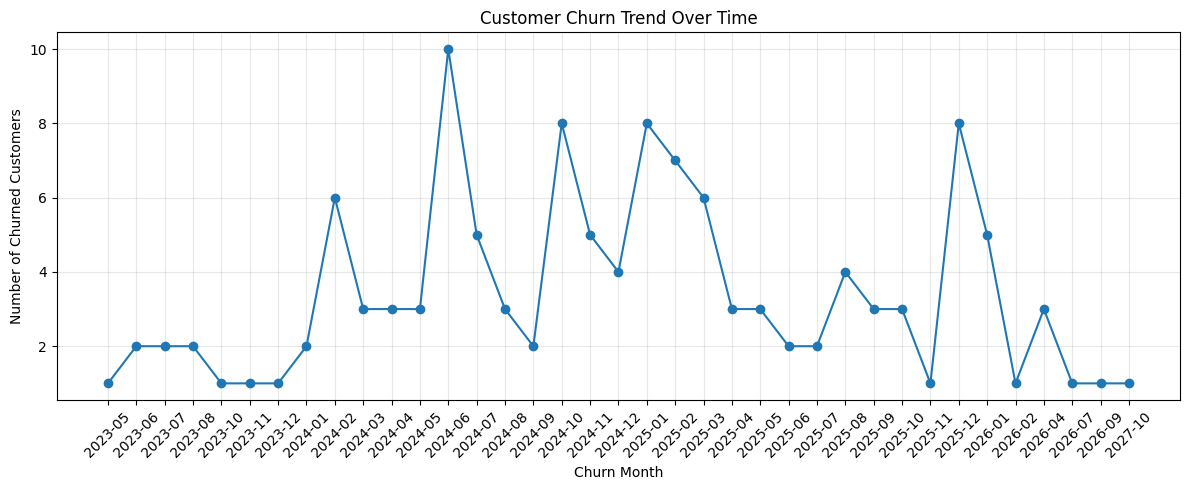

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    churn_trend['ChurnMonth'],
    churn_trend['ChurnedCustomers'],
    marker='o'
)

plt.title('Customer Churn Trend Over Time')
plt.xlabel('Churn Month')
plt.ylabel('Number of Churned Customers')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# INSIGHTS:
Churn was high in JUNE 2024(10 CUSTOMERS)

In [ ]:
# CHART - 2 : RETENTION CURVE :

retention_curve

,Retained
CohortIndex,
0,99.507389
1,99.234694
2,99.193548
3,98.863636
4,99.395770
5,98.322148
6,99.637681
7,97.286822
8,97.489540


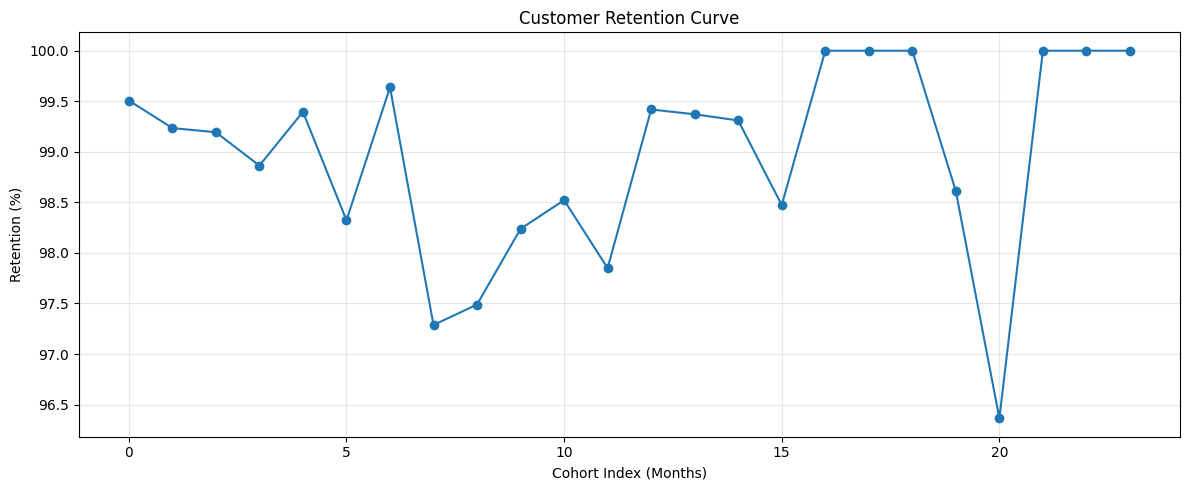

In [ ]:
cohort_index = [
    0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
    12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23
]

retention = [
    99.507389, 99.234694, 99.193548, 98.863636,
    99.395770, 98.322148, 99.637681, 97.286822,
    97.489540, 98.237885, 98.522167, 97.849462,
    99.418605, 99.371069, 99.310345, 98.473282,
    100.000000, 100.000000, 100.000000, 98.611111,
    96.363636, 100.000000, 100.000000, 100.000000
]

plt.figure(figsize=(12, 5))

plt.plot(
    cohort_index,
    retention,
    marker='o'
)

plt.title('Customer Retention Curve')
plt.xlabel('Cohort Index (Months)')
plt.ylabel('Retention (%)')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# INSIGHTS:

RETENTION  IS LOWEST 96.363636 AT MONTH 20

In [ ]:
# CHART - 3 : CHURN BY SEGMENT:

churn_segment = subscriptions.merge(
    customers[['CustomerID', 'Industry']],
    on='CustomerID',
    how='left'
)

churn_segment = churn_segment[
    churn_segment['Status'] == 'Churned'
]

churn_by_segment = (
    churn_segment['Industry']
    .value_counts()
    .reset_index()
)

churn_by_segment.columns = ['Industry', 'ChurnedCustomers']

churn_by_segment

,Industry,ChurnedCustomers
0,Logistics,21
1,Finance,21
2,Manufacturing,18
3,Retail,18
4,Healthcare,16
5,Media,14
6,Education,14


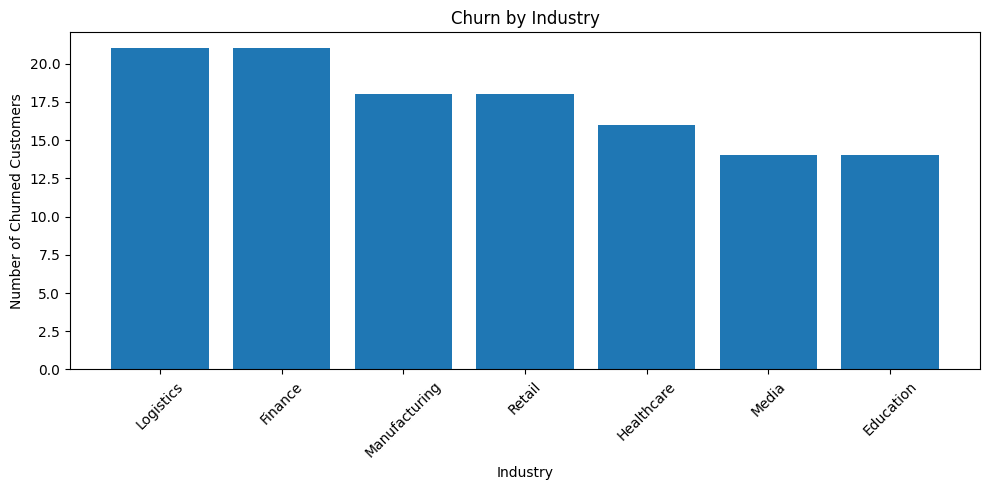

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    churn_by_segment['Industry'],
    churn_by_segment['ChurnedCustomers']
)

plt.title('Churn by Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Churned Customers')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#INSIGHT:
LOGISTICS AND FINANCE HAS HIGHEST CHURN  21 EACH

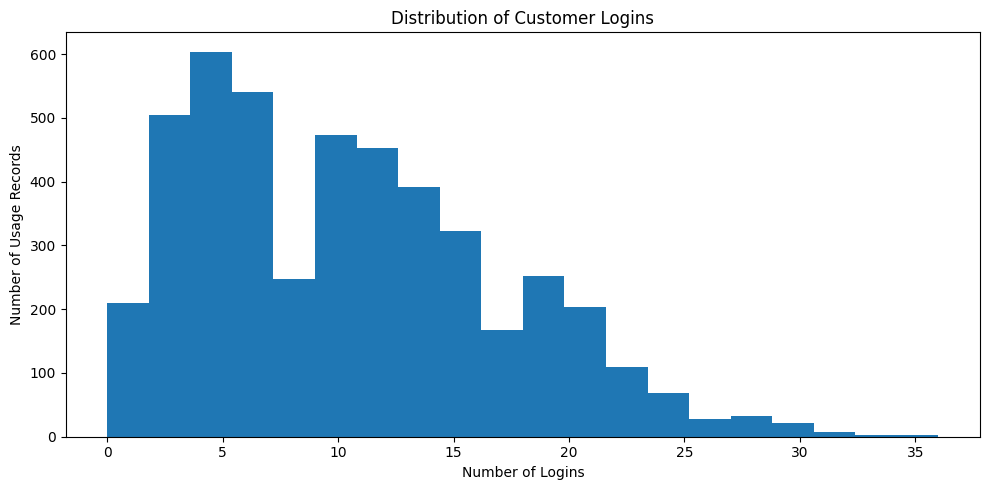

In [ ]:
#CHART - 4 : USAGE DISTRIBUTION:
plt.figure(figsize=(10, 5))

plt.hist(
    usage['Logins'].dropna(),
    bins=20
)

plt.title('Distribution of Customer Logins')
plt.xlabel('Number of Logins')
plt.ylabel('Number of Usage Records')

plt.tight_layout()
plt.show()

In [ ]:
usage['Logins'].describe()

,Logins
count,4640.000000
mean,10.346767
std,6.556650
min,0.000000
25%,5.000000
50%,9.000000
75%,15.000000
max,36.000000


In [ ]:
#USAGE VS CHURB RELATION:

usage_churn = (
    usage.merge(
        subscriptions[['SubscriptionID', 'Status']],
        on='SubscriptionID',
        how='left'
    )
    .groupby('Status')['Logins']
    .mean()
    .reset_index()
)

usage_churn

,Status,Logins
0,Active,11.180977
1,Churned,7.210974
2,Paused,13.806452


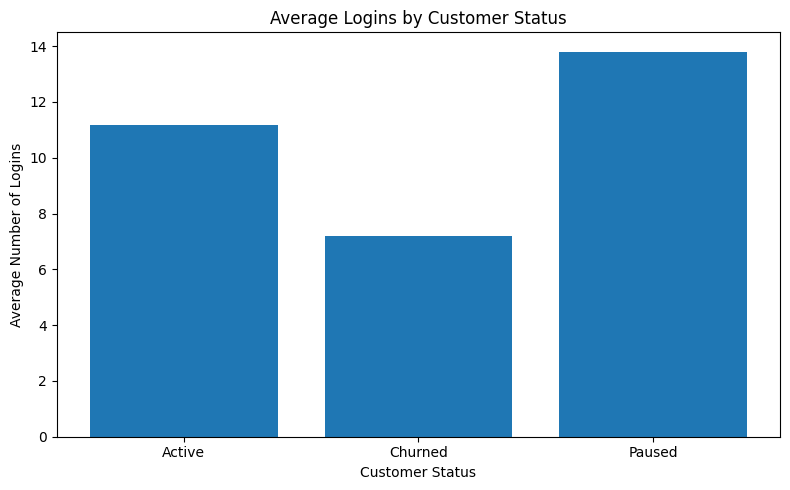

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    usage_churn['Status'],
    usage_churn['Logins']
)

plt.title('Average Logins by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Average Number of Logins')

plt.tight_layout()
plt.show()

# INSIGHTS:

CHURNED CUSTOMERS IS LOW LOGIN(7.21) THAN ACTIVE CUSTOMERS(11.18)

In [ ]:
# CHART-5 : TICKET SATISFACTION  IMPACT :
ticket_impact = (
    support_tickets.merge(
        subscriptions[['CustomerID', 'Status']],
        on='CustomerID',
        how='left'
    )
    .groupby('Status')['SatisfactionScore']
    .mean()
    .reset_index()
)

ticket_impact

,Status,SatisfactionScore
0,Active,5.560926
1,Churned,5.502551
2,Paused,6.000000


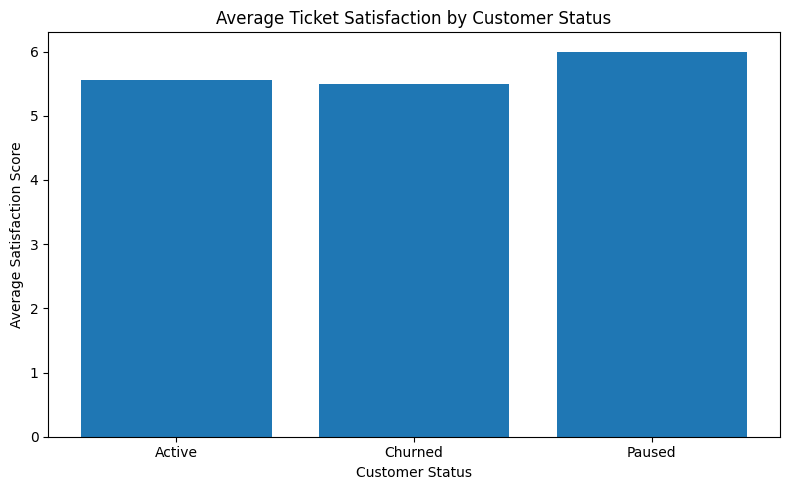

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    ticket_impact['Status'],
    ticket_impact['SatisfactionScore']
)

plt.title('Average Ticket Satisfaction by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Average Satisfaction Score')

plt.tight_layout()
plt.show()

# INSIGHTS :      
Churned customers had a slightly lower average satisfaction score (5.50) than active customers (5.56), while paused customers had the highest score (6.00).

In [ ]:
# CHART - 7 : CORRELATION HEATMAP:

# CORRELATION MATRIX :
corr_data = usage[
    ['Logins', 'ActiveUsers', 'APICalls', 'SessionMinutes']
]

corr_matrix = corr_data.corr()

corr_matrix

,Logins,ActiveUsers,APICalls,SessionMinutes
Logins,1.000000,0.877740,0.072625,0.173370
ActiveUsers,0.877740,1.000000,0.060050,0.157651
APICalls,0.072625,0.060050,1.000000,0.124270
SessionMinutes,0.173370,0.157651,0.124270,1.000000


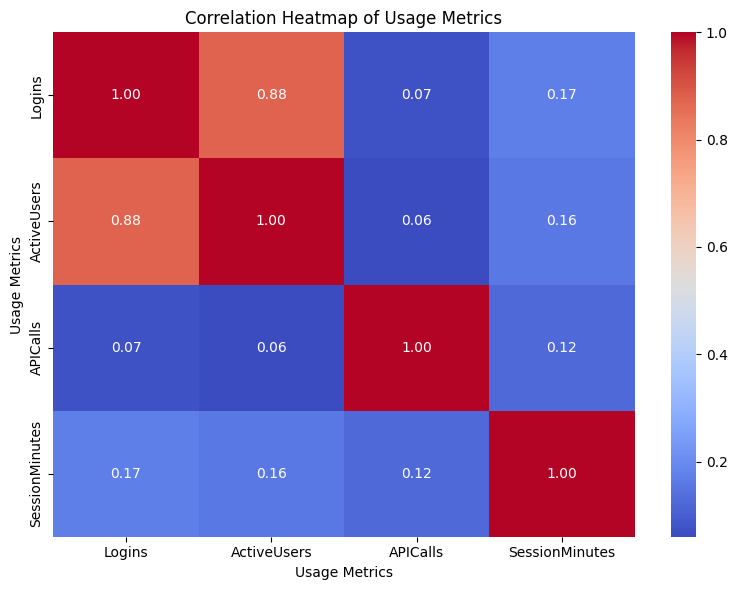

In [ ]:
import seaborn as sns


plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Usage Metrics')
plt.xlabel('Usage Metrics')
plt.ylabel('Usage Metrics')

plt.tight_layout()
plt.show()

#INSIGHTS:

Logins and ActiveUsers have a strong positive correlation of 0.88, while the other usage metrics show weak correlations.

# MODULE 8: CUSTOMER SEGMENTATION:



In [ ]:
# 1. Subscription features
subscription_features = (
    subscriptions.groupby('CustomerID')
    .agg({
        'MRR': 'mean',
        'Seats': 'mean'
    })
    .reset_index()
)

# 2. Usage features
usage_features = (
    usage.groupby('CustomerID')
    .agg({
        'Logins': 'mean',
        'ActiveUsers': 'mean',
        'APICalls': 'mean',
        'SessionMinutes': 'mean'
    })
    .reset_index()

)

# 3. Support ticket features
ticket_features = (
    support_tickets.groupby('CustomerID')
    .agg({
        'TicketID': 'count',
        'SatisfactionScore': 'mean'
    })
    .reset_index()
)

ticket_features = ticket_features.rename(
    columns={'TicketID': 'Tickets'}
)

# 4. Merge everything
customer_features = (
    subscription_features
    .merge(usage_features, on='CustomerID', how='left')
    .merge(ticket_features, on='CustomerID', how='left')
)

customer_features.head()

,CustomerID,MRR,Seats,Logins,ActiveUsers,APICalls,SessionMinutes,Tickets,SatisfactionScore
0,C1001,278.60,6.0,9.250000,4.500000,642.250000,140.087500,4.0,6.5
1,C1002,246.76,4.0,19.727273,12.181818,1410.181818,274.645455,4.0,7.0
2,C1003,278.60,6.0,11.687500,7.400000,1235.687500,295.887500,3.0,3.0
3,C1004,80.36,9.0,8.200000,4.200000,1401.200000,253.000000,NaN,NaN
4,C1005,618.76,4.0,10.230769,4.692308,1017.846154,161.692308,3.0,6.0


In [ ]:
customer_features.shape

(420, 9)

In [ ]:
customer_features.isnull().sum()

,0
CustomerID,0
MRR,7
Seats,4
Logins,14
ActiveUsers,14
APICalls,14
SessionMinutes,14
Tickets,10
SatisfactionScore,12


In [ ]:
feature_columns = [
    'MRR',
    'Seats',
    'Logins',
    'ActiveUsers',
    'APICalls',
    'SessionMinutes',
    'Tickets',
    'SatisfactionScore'
]

customer_features[feature_columns] = (
    customer_features[feature_columns]
    .fillna(customer_features[feature_columns].median())
)

In [ ]:
customer_features.isnull().sum()

,0
CustomerID,0
MRR,0
Seats,0
Logins,0
ActiveUsers,0
APICalls,0
SessionMinutes,0
Tickets,0
SatisfactionScore,0


In [ ]:
# STANDARDSCALER:

from sklearn.preprocessing import StandardScaler

feature_columns = ['MRR','Seats','Logins','ActiveUsers','APICalls','SessionMinutes','Tickets','SatisfactionScore'
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    customer_features[feature_columns]
)

In [ ]:
X_scaled.shape

(420, 8)

In [ ]:
# ELBOW METHOD :

from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

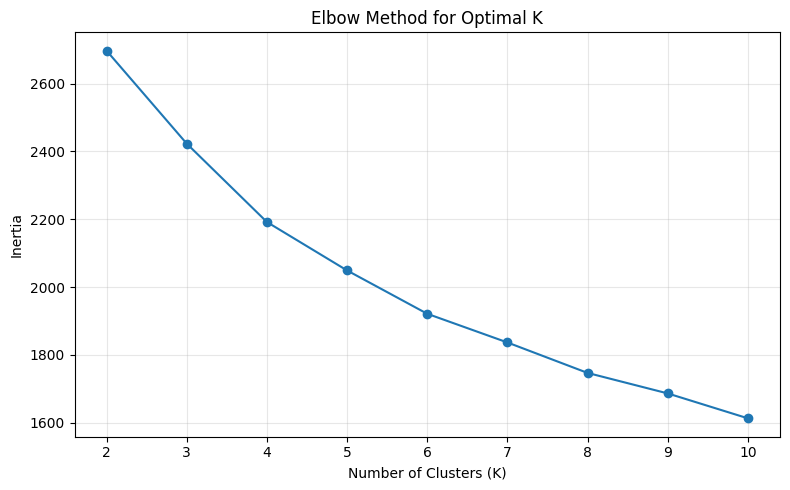

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
for k, value in zip(range(2, 11), inertia):
    print(f"K={k}: Inertia={value:.2f}")

K=2: Inertia=2697.17
K=3: Inertia=2423.07
K=4: Inertia=2192.00
K=5: Inertia=2049.20
K=6: Inertia=1921.45
K=7: Inertia=1836.87
K=8: Inertia=1747.04
K=9: Inertia=1686.59
K=10: Inertia=1613.15


In [ ]:
# K=4:

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_features['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
customer_features['Cluster'].value_counts().sort_index()

,count
Cluster,
0,151
1,51
2,114
3,104


In [ ]:
cluster_profile = (
    customer_features
    .groupby('Cluster')[feature_columns]
    .mean()
    .round(2)
)

cluster_profile

,MRR,Seats,Logins,ActiveUsers,APICalls,SessionMinutes,Tickets,SatisfactionScore
Cluster,,,,,,,,
0,325.16,6.81,6.72,3.51,1329.40,251.97,3.32,5.34
1,2197.36,6.82,12.42,7.14,1106.74,247.58,3.82,5.43
2,351.60,7.03,16.93,9.70,1317.70,254.97,3.31,5.99
3,474.71,6.83,6.67,3.43,750.44,162.67,3.23,5.31


# CLUSTER - 1 :    HIGH VALUE POWER CUSTOMERS:
* 51 customers
* Highest MRR: 2,197
* High logins: 12.42
* High active users: 7.14
* Provide personalized support

# CLUSTER - 2: HIGHLY ENGAGED USERS:
* 114 customers
* Highest logins: 16.93
* Highest active users: 9.70
* Highest satisfaction: 5.99
* Highest session time: 255 min
*use more advanced features

# CLUSTER - 3: LOW ENGAGED CUTOMERS:
* 104 customers
* Low logins: 6.67
* Lowest active users: 3.43
* Lowest session time: 163 min
* Lowest satisfaction: 5.31
* Provide onboarding and engagement support.


# MODULE 9 : CHURN RISK SCORING

In [ ]:
risk_features = [
    'Logins',
    'ActiveUsers',
    'SessionMinutes',
    'SatisfactionScore'
]

for feature in risk_features:
    median_value = customer_features[feature].median()

    customer_features[feature + '_Risk'] = (
        customer_features[feature] < median_value
    ).astype(int)

customer_features['RiskScore'] = (
    customer_features['Logins_Risk']
    + customer_features['ActiveUsers_Risk']
    + customer_features['SessionMinutes_Risk']
    + customer_features['SatisfactionScore_Risk']
)


In [ ]:
customer_features['RiskScore'].value_counts().sort_index()

,count
RiskScore,
0,79
1,95
2,81
3,118
4,47


In [ ]:
# RANK CUSTOMER BY RISK :
customer_features = customer_features.sort_values(
    by='RiskScore',
    ascending=False
)

customer_features[
    ['CustomerID', 'MRR', 'RiskScore']
].head(20)

,CustomerID,MRR,RiskScore
397,C1398,326.36,4
400,C1401,342.28,4
25,C1026,698.60,4
47,C1048,658.68,4
374,C1375,68.60,4
377,C1378,191.60,4
37,C1038,246.76,4
65,C1066,88.20,4
61,C1062,358.20,4
62,C1063,56.84,4


In [ ]:
# FIND HIGHEST RISK GROUP :

high_risk = customer_features[
    customer_features['RiskScore'] >= 3
]

high_risk.shape

(165, 15)

In [ ]:
high_risk_mrr = high_risk['MRR'].sum()

high_risk_mrr

np.float64(78844.68000000001)

In [ ]:
total_mrr = customer_features['MRR'].sum()

high_risk_mrr_pct = (
    high_risk_mrr / total_mrr
) * 100

high_risk_mrr_pct

np.float64(31.460142795991093)

I created a churn risk score using four behavioural signals: Logins, ActiveUsers, SessionMinutes, and SatisfactionScore. Customers were ranked by risk, and customers with a score of 3–4 were classified as high risk. The high-risk group represents ₹78844.68 of MRR.

In [ ]:
customers.to_csv("customers_clean.csv", index=False)
subscriptions.to_csv("subscription_clean.csv", index=False)
usage.to_csv("usage_clean.csv", index=False)
support_tickets.to_csv("support_ticket_clean.csv", index=False)

In [ ]:
import pandas as pd

file_path = "CloudMetrics_Excel_Report.xlsx"

with pd.ExcelWriter(file_path, engine="openpyxl") as writer:
    customers.to_excel(writer, sheet_name="Customers", index=False)
    subscriptions.to_excel(writer, sheet_name="Subscription", index=False)
    usage.to_excel(writer, sheet_name="Usage", index=False)
    support_tickets.to_excel(writer, sheet_name="Support_Ticket", index=False)

print("Step 1 completed - Cleaned data exported!")

Step 1 completed - Cleaned data exported!


In [ ]:
#CREATE PIVOT TABLE :

pivot_summary = pd.pivot_table(
    subscriptions,
    index="PlanName",
    columns="Status",
    values="MRR",
    aggfunc="sum",
    fill_value=0
)


In [ ]:
with pd.ExcelWriter(
    file_path,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    pivot_summary.to_excel(
        writer,
        sheet_name="Pivot_Summary"
    )

print("Step 2 completed - Pivot Summary added!")

Step 2 completed - Pivot Summary added!


In [ ]:
#CREATE KPI SHEETS:

from openpyxl import load_workbook

wb = load_workbook(file_path)

if "KPI" in wb.sheetnames:
    del wb["KPI"]

ws = wb.create_sheet("KPI")

ws["A1"] = "CloudMetrics KPI Report"

ws["A3"] = "KPI"
ws["B3"] = "Value"

In [ ]:
#TOTAL MRR FORMULA :

ws["A4"] = "Total MRR"
ws["B4"] = "=SUM(Subscription!I:I)"

In [ ]:
ws["B4"] = "=SUM(Subscription!F:F)"

In [ ]:
# CHURN RATE FORMULA :

ws["A5"] = "Churn Rate"

ws["B5"] = (
    '=COUNTIF(Subscription!I:I,"Churned")/'
    'COUNTA(Subscription!B:B)'
)

In [ ]:
ws["B5"] = (
    '=COUNTIF(Subscription!I:I,"Churned")/'
    'COUNTA(Customers!A:A)'
)

In [ ]:
#AVERAGE REVENUE PER ACCOUNT :

ws["A6"] = "Average Revenue per Account"

ws["B6"] = (
    "=SUM(Subscription!F:F)/COUNTA(Customers!A:A)"
)

In [ ]:
#AVERAGE TENURE :

sub_ws = wb["Subscription"]

sub_ws["J1"] = "TenureDays"

In [ ]:
for row in range(2, sub_ws.max_row + 1):

    sub_ws[f"J{row}"] = (
        f'=IF(H{row}="",TODAY()-G{row},H{row}-G{row})'
    )

In [ ]:
ws["A7"] = "Average Tenure"

ws["B7"] = "=AVERAGE(Subscription!J:J)"

In [ ]:
#KPI SHEET :

ws["A1"] = "CloudMetrics KPI Report"

ws["A1"].font = ws["A1"].font.copy(bold=True, size=16)
ws["A3"].font = ws["A3"].font.copy(bold=True)
ws["B3"].font = ws["B3"].font.copy(bold=True)

ws.column_dimensions["A"].width = 30
ws.column_dimensions["B"].width = 20

In [ ]:
ws["B4"].number_format = '#,##0.00'
ws["B6"].number_format = '#,##0.00'

In [ ]:
ws["B5"].number_format = '0.00%'

In [ ]:
ws["B7"].number_format = '0.00'

In [ ]:
#SAVE :

wb.save(file_path)

print("Module 11 completed successfully!")
print("File:", file_path)

Module 11 completed successfully!
File: CloudMetrics_Excel_Report.xlsx


In [ ]:
from openpyxl import load_workbook

wb = load_workbook(file_path, data_only=False)
ws = wb["KPI"]

for cell in ["B4", "B5", "B6", "B7"]:
    print(cell, ws[cell].value)

B4 =SUM(Subscription!F:F)
B5 =COUNTIF(Subscription!I:I,"Churned")/COUNTA(Customers!A:A)
B6 =SUM(Subscription!F:F)/COUNTA(Customers!A:A)
B7 =AVERAGE(Subscription!J:J)


In [ ]:
customer_features.to_csv(
    "customer_risk.csv",
    index=False
)

In [ ]:
retention_table.to_csv(
    "cohort_retentions.csv",
    index=False
)